# Machine Learning for Lung Cancer Prediction: An End-to-End Classification Exercise


## Objective
Develop and evaluate a supervised classification model that predicts lung cancer from patient symptoms and determine the critical predictive features from the provided dataset.



<!-- generated-team-badges: run `python scripts/update_notebook_badges.py` to refresh -->
<div align="center"><img alt="Hours" src="https://img.shields.io/badge/Hours-8h%2014m-4A4A4A?style=flat-square&logo=git&logoColor=white&labelColor=1F6FEB" /> <a href="https://github.com/jamesbarlow1812"><img alt="James Barlow" src="https://img.shields.io/badge/%20-James%20Barlow-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=7C3AED" /></a> <a href="https://github.com/JoeShade"><img alt="Joe Shade" src="https://img.shields.io/badge/%20-Joe%20Shade-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=D97706" /></a> <a href="https://github.com/Nomo2001"><img alt="Lena Kraemer" src="https://img.shields.io/badge/%20-Lena%20Kraemer-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=059669" /></a> <a href="https://github.com/SimonAndreou"><img alt="Simon Andreou" src="https://img.shields.io/badge/%20-Simon%20Andreou-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=DC2626" /></a></div>




<table style="margin-left: auto; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: center;">Team member</th>
      <th style="text-align: center;">Main responsibility</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;">James Barlow</td>
      <td style="text-align: center;">Feature Engineer</td>
    </tr>
    <tr>
      <td style="text-align: center;">Joe Shade</td>
      <td style="text-align: center;">Coding, repo governance</td>
    </tr>
    <tr>
      <td style="text-align: center;">Lena Kraemer</td>
      <td style="text-align: center;">ML Engineer, Model Builder</td>
    </tr>
    <tr>
      <td style="text-align: center;">Simon Andreou</td>
      <td style="text-align: center;">Data Scientist/ Coordinator</td>
    </tr>
  </tbody>
</table>

<p style="text-align: center;"><em>Table 1, Student Contribution Matrix</em></p>

## 1. Problem Definition and Plan


### 1.1 ML task definition

The machine learning task is a supervised binary classification, the target variable is "LUNG_CANCER" which is either true or false. We want to learn a mapping from patient feature to the target label so that the model can classify whether a patient record is indicative of lung cancer, yes or no. 

Due to the severe imbalance in the data set accuracy alone is not a sufficient metric to evaluate the model. A model can get high accuracy by overpredicting the majorirty class. 

### 1.2 Why this problem matters




Lung cancer is a serious health condition, improving how high-risk cases are identified may have a positive impact on health outcomes. 
Through this exercise we can also identify what features are strong indicators of lung cancer. 

Academically this challenge is also valuable, it is a strong example of responsible machine learning practice. The importance of context and real life consequences of poor engineering thinking. 

# 2. Data Preparation


## 2.1 Dataset overview
The notebook uses `datasets/givenData.csv` as the canonical input file. The raw dataset contains 309 rows and 16 columns: one binary target (`LUNG_CANCER`), one age field, one gender field, and 13 symptom or lifestyle indicators. `LUNG_CANCER` is the label the models will try to predict, while the remaining columns are candidate features available before prediction.


In [1]:
# import Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

notebook_primary_color = '#B300C2'
notebook_secondary_color = '#0082E5'
notebook_primary_light = '#E3A6EA'
notebook_secondary_light = '#9FD2FF'
notebook_neutral_color = '#3A3A3A'
notebook_sequential_cmap = LinearSegmentedColormap.from_list(
    'notebook_sequential_cmap',
    ['#F7F9FC', notebook_secondary_color, notebook_primary_color],
)
notebook_diverging_cmap = LinearSegmentedColormap.from_list(
    'notebook_diverging_cmap',
    [notebook_secondary_color, '#F7F9FC', notebook_primary_color],
)

def notebook_matrix_text_color(value: float, threshold: float) -> str:
    return 'white' if value > threshold else notebook_neutral_color

# Import the Scikit-Learn framework
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler


In [2]:
dataset = pd.read_csv("datasets/givenData.csv", thousands=",")
dataset.columns = dataset.columns.str.strip()

dataset.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


<p style="text-align: center;"><em>Table 2, Raw data preview</em></p>

### 2.1.1 Column definitions
<table style='width: 100%; border-collapse: collapse; border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>
  <thead>
    <tr style='background-color: #eceaea; color: #000000;'>
      <th style='padding: 8px; text-align: left; border: none !important;'>COLUMN</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>TYPE</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>NOTES</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>RAW ENCODING</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>NEW ENCODING</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>LUNG_CANCER</code></td><td style='padding: 8px; border: none !important;'>Binary target</td><td style='padding: 8px; border: none !important;'>Whether the patient is labelled as having lung cancer</td><td style='padding: 8px; border: none !important;'><code>YES</code> / <code>NO</code></td><td style='padding: 8px; border: none !important;'><code>1</code> = cancer, <code>0</code> = no cancer</td></tr>
    <tr><td colspan='5' style='padding: 8px; border: none !important; background-color: #eceaea; color: #000000; font-weight: bold; text-align: center;'>PREDICTOR VARIABLES</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>GENDER</code></td><td style='padding: 8px; border: none !important;'>Categorical</td><td style='padding: 8px; border: none !important;'>Recorded patient sex/gender</td><td style='padding: 8px; border: none !important;'><code>M</code> / <code>F</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = male, <code>1</code> = female</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>AGE</code></td><td style='padding: 8px; border: none !important;'>Numeric</td><td style='padding: 8px; border: none !important;'>Patient age in years</td><td style='padding: 8px; border: none !important;'>Integer-valued</td><td style='padding: 8px; border: none !important;'>Kept numeric; later min-max scaled in the model pipeline</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>SMOKING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether the patient is recorded as smoking</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code> in the raw data</td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>YELLOW_FINGERS</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether yellow fingers are recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ANXIETY</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether anxiety is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>PEER_PRESSURE</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether peer pressure is recorded as a factor</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>CHRONIC DISEASE</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether chronic disease is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>FATIGUE </code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether fatigue is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ALLERGY </code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether allergy is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>WHEEZING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether wheezing is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ALCOHOL CONSUMING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether alcohol consumption is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>COUGHING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether coughing is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>SHORTNESS OF BREATH</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether shortness of breath is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>SWALLOWING DIFFICULTY</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether swallowing difficulty is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>CHEST PAIN</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether chest pain is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
  </tbody>
</table>
<p style='text-align: center; margin-top: 8px; color: #000000;'><em>Table 3, Raw column definitions</em></p>

**Note:** Most non-target binary variables are encoded as <code>1</code>/<code>2</code> rather than <code>0</code>/<code>1</code>, a few  column names contain spacing issues.

### 2.1.2 Initial observations
First inspection showed three practical preparation issues: duplicated rows, several column names with spaces or trailing whitespace, and binary variables encoded as `1/2` rather than `0/1`. These need explicit handling before being parsed to the model.


## 2.2 Data quality checks



### 2.2.1 Missing data
No missing values were found in the raw file. Preparation therefore focuses on duplicate handling, consistent recoding, and a small amount of interpretable feature engineering rather than imputation.


In [3]:
# Summarise completeness and data types, then render a centred HTML table
try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

missing_data_summary = pd.DataFrame(
    {
        "Column": dataset.columns,
        "Data type": dataset.dtypes.astype(str).values,
        "Non-null count": dataset.notna().sum().values,
        "Missing values": dataset.isna().sum().values,
    }
)

missing_data_summary["Completeness (%)"] = (
    missing_data_summary["Non-null count"] / len(dataset) * 100
).round(1)

target_row = missing_data_summary.loc[
    missing_data_summary["Column"] == "LUNG_CANCER"
].copy()
predictor_rows = missing_data_summary.loc[
    missing_data_summary["Column"] != "LUNG_CANCER"
].copy()

def _summary_row_to_html(row: pd.Series, background: str) -> str:
    return (
        f"<tr style='background-color: {background};'>"
        f"<td style='padding: 8px; border: none !important;'><code>{row['Column']}</code></td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Data type']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Non-null count']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Missing values']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Completeness (%)']:.1f}%</td>"
        "</tr>"
    )

html_rows = []
html_rows.append(_summary_row_to_html(target_row.iloc[0], "#fbfbfb"))
html_rows.append(
    "<tr><td colspan='5' style='padding: 8px; border: none !important; "
    "background-color: #eceaea; color: #000000; font-weight: bold; text-align: center;'>"
    "PREDICTOR VARIABLES"
    "</td></tr>"
)

for index, (_, row) in enumerate(predictor_rows.iterrows()):
    background = "#fbfbfb" if index % 2 == 0 else "#f4f2f2"
    html_rows.append(_summary_row_to_html(row, background))

missing_data_summary_html = "".join(
    [
        "<div style='width: 100%; text-align: center;'>",
        "<table style='width: 92%; margin: 0 auto; border-collapse: collapse; "
        "border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>",
        "<thead>",
        "<tr style='background-color: #eceaea; color: #000000;'>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>COLUMN</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>DATA TYPE</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>NON-NULL COUNT</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>MISSING VALUES</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>COMPLETENESS (%)</th>",
        "</tr>",
        "</thead>",
        "<tbody>",
        *html_rows,
        "</tbody>",
        "</table>",
        "</div>",
    ]
)

if HTML is not None and display is not None:
    display(HTML(missing_data_summary_html))
else:
    print(missing_data_summary.to_string(index=False))

<p style='text-align: center; margin-top: 8px; color: #000000;'><em>Table 4, Data completeness summary</em></p>

### 2.2.2 De-duplication
The raw dataset contains 309 rows, with a duplicate-heavy block at the end of the file. Within the final 30 raw rows, 25 are flagged as exact duplicates of earlier records, while only 8 exact duplicate flags appear across all earlier rows combined. For this notebook, the final 30 rows are treated as the most likely erroneous appended segment and removed as a whole, including the five rows in that block that are not individually flagged by `duplicated()`. Earlier repeated rows are retained on the assumption that they belong to the original dataset rather than to the later append. This rule leaves 279 rows in the working dataset for the remaining analysis.


In [4]:
# Summarise the final-row trimming decision in a centred HTML table.
try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

duplicate_flags = dataset.duplicated()
raw_row_count = len(dataset)
duplicate_row_count = int(duplicate_flags.sum())
final_block_size = 30
working_row_count = raw_row_count - final_block_size
retained_earlier_duplicate_count = int(dataset.iloc[:-final_block_size].duplicated().sum())

def _render_centered_html_table(
    table_df: pd.DataFrame, caption: str, width: str = "70%"
) -> str:
    header_html = "".join(
        f"<th style='padding: 8px; text-align: center; border: none !important;'>{column.upper()}</th>"
        for column in table_df.columns
    )

    body_rows = []
    for index, (_, row) in enumerate(table_df.iterrows()):
        background = "#fbfbfb" if index % 2 == 0 else "#f4f2f2"
        row_html = "".join(
            f"<td style='padding: 8px; text-align: center; border: none !important;'>{value}</td>"
            for value in row
        )
        body_rows.append(f"<tr style='background-color: {background};'>{row_html}</tr>")

    return "".join(
        [
            "<div style='width: 100%; text-align: center;'>",
            f"<table style='width: {width}; margin: 0 auto; border-collapse: collapse; border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>",
            "<thead>",
            "<tr style='background-color: #eceaea; color: #000000;'>",
            header_html,
            "</tr>",
            "</thead>",
            "<tbody>",
            *body_rows,
            "</tbody>",
            "</table>",
            f"<p style='text-align: center; margin-top: 8px; color: #000000;'><em>{caption}</em></p>",
            "</div>",
        ]
    )

dedup_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Raw rows",
            "Final raw rows removed",
            "Working rows after removal",
            "Exact duplicate flags within full raw file",
            "Exact duplicate flags retained earlier in file",
            "Rule applied",
        ],
        "Value": [
            raw_row_count,
            final_block_size,
            working_row_count,
            duplicate_row_count,
            retained_earlier_duplicate_count,
            "Exclude the final <code>30</code> raw rows as one block",
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        dedup_summary_df,
        "Table 5, De-duplication summary",
        width="72%",
    )))
else:
    print(dedup_summary_df.to_string(index=False))


METRIC,VALUE
Raw rows,309
Final raw rows removed,30
Working rows after removal,279
Exact duplicate flags within full raw file,33
Exact duplicate flags retained earlier in file,8
Rule applied,Exclude the final 30 raw rows as one block


In [5]:
# Show why the final block was treated as the suspicious appended segment.
final_segment_size = final_block_size
final_segment_duplicate_count = int(duplicate_flags.tail(final_segment_size).sum())
earlier_segment_size = raw_row_count - final_segment_size
earlier_segment_duplicate_count = duplicate_row_count - final_segment_duplicate_count

duplicate_distribution_df = pd.DataFrame(
    {
        "Location in raw file": [
            f"Final {final_segment_size} raw rows",
            "Earlier raw rows",
        ],
        "Rows flagged by duplicated()": [
            f"{final_segment_duplicate_count} of {final_segment_size}",
            f"{earlier_segment_duplicate_count} of {earlier_segment_size}",
        ],
        "Flagged share": [
            f"{final_segment_duplicate_count / final_segment_size * 100:.1f}%",
            f"{earlier_segment_duplicate_count / earlier_segment_size * 100:.1f}%",
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        duplicate_distribution_df,
        "Table 6, Duplicate distribution evidence",
        width="68%",
    )))
else:
    print(duplicate_distribution_df.to_string(index=False))


LOCATION IN RAW FILE,ROWS FLAGGED BY DUPLICATED(),FLAGGED SHARE
Final 30 raw rows,25 of 30,83.3%
Earlier raw rows,8 of 279,2.9%


These two tables support treating the final 30 rows as the suspicious appended block. The notebook therefore excludes that whole tail segment from modelling, while leaving earlier repeated rows unchanged.


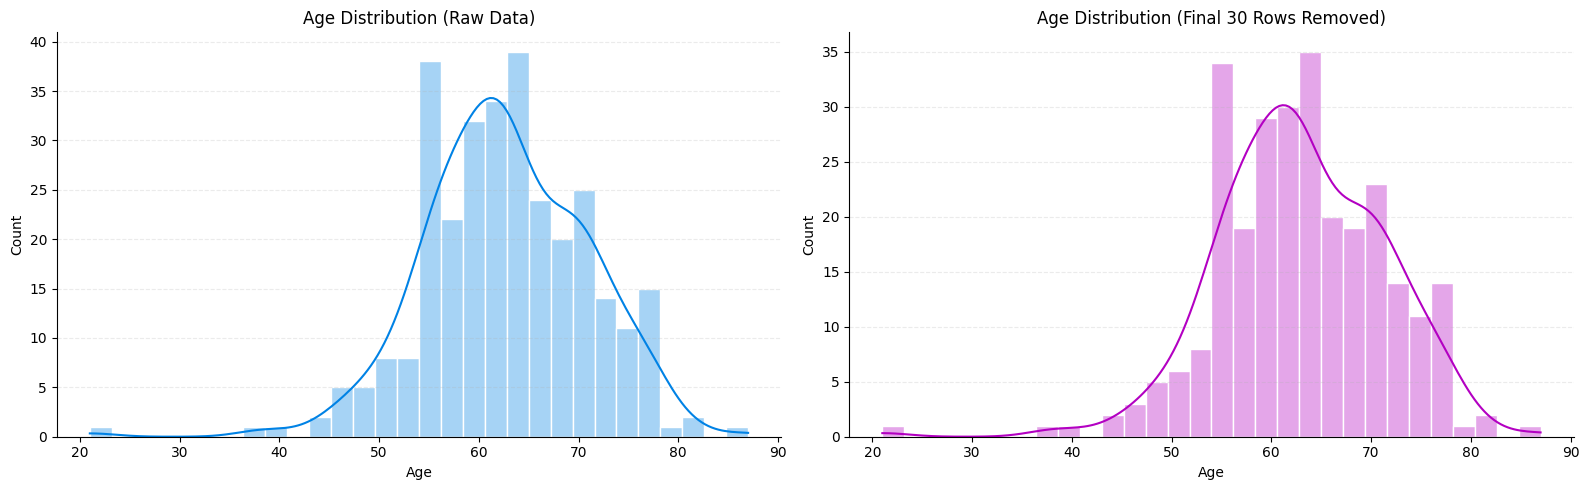

In [6]:
# Build the working dataset by excluding the suspicious final 30-row block.
dataset_dedup = dataset.iloc[:-30].reset_index(drop=True).copy()

# Compare the age distribution before and after removing the final raw-row block.
age_compare_fig, age_compare_axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
    data=dataset,
    x='AGE',
    bins=30,
    kde=True,
    color=notebook_secondary_color,
    alpha=0.35,
    edgecolor='white',
    ax=age_compare_axes[0],
)
age_compare_axes[0].set_title('Age Distribution (Raw Data)')
age_compare_axes[0].set_xlabel('Age')
age_compare_axes[0].set_ylabel('Count')

sns.histplot(
    data=dataset_dedup,
    x='AGE',
    bins=30,
    kde=True,
    color=notebook_primary_color,
    alpha=0.35,
    edgecolor='white',
    ax=age_compare_axes[1],
)
age_compare_axes[1].set_title('Age Distribution (Final 30 Rows Removed)')
age_compare_axes[1].set_xlabel('Age')
age_compare_axes[1].set_ylabel('Count')

for axis in age_compare_axes:
    axis.grid(axis='y', linestyle='--', alpha=0.25)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

age_compare_fig.tight_layout()
plt.show()


<p style='text-align: center;'><em>Figure 3. Age distribution before and after removing the final 30 rows.</em></p>

The two histograms retain a very similar overall shape after the final 30 rows are removed, with no obvious shift in the main concentration of ages. This suggests that the de-duplication step reduces the influence of the suspicious appended block without materially changing the age profile of the working dataset, so later modelling is less exposed to duplicate-driven bias while remaining representative of the original sample structure.


## 2.2.3 Outlier review
Only `AGE` required a conventional outlier check because the remaining predictors are binary or categorical. We reviewed the age distribution on the working dataset after excluding the final 30 raw rows and used an interquartile-range rule to identify outliers.


### 2.2.3.1 Age outliers
The IQR rule flags four ages outside the approximate 40.9 to 85.9 range: 21, 38, 39, and 87. These values are unusual relative to the middle of the sample, but they are still plausible ages rather than obvious errors. The youngest flagged record is a 21-year-old female, which is unusual in this dataset but still credible enough to discuss rather than discard automatically.


### 2.2.3.2 Decision on outliers
No age records were removed. With only one continuous predictor, deleting rare but plausible ages would shrink an already small dataset and risk hiding real variation, so the notebook keeps all observed ages, including the 21-year-old female case, and treats them as part of the sample spread.


## 2.2.4 Encoding and preprocessing decisions
Most predictors are already categorical or binary in meaning, but the raw file stores them in a form that still needs consistent recoding. We standardised column names, mapped the target to `0/1`, recoded the binary predictors to `0/1`, and kept the final learned preprocessing steps inside the later modelling pipelines.

### 2.2.4.1 Target encoding
The target variable was originally stored as text (`YES` and `NO`). It was converted to binary form (`1` for lung cancer and `0` for no lung cancer) so that the classifiers and evaluation metrics can operate consistently.

### 2.2.4.2 Feature encoding
The symptom and lifestyle predictors were recoded from `1/2` to `0/1`, and `GENDER` was mapped from `M/F` to `0/1`. `AGE` remains numeric in the working dataset but is min-max normalised to the `0-1` range inside the shared preprocessing pipeline, while `AGE_BINS` is retained as a categorical feature and one-hot encoded there as well.

### 2.2.4.3 Scaling strategy
Scaling is useful for the logistic-regression baseline and harmless when applied consistently across models, so numeric features are standardised inside the common pipeline. Tree-based models do not need scaling for correctness, but using the same preprocessing structure keeps the comparison fair and leakage-safe.

### 2.2.4.4 Leakage prevention
All learned preprocessing steps are fitted only inside the training folds during cross-validation and only on the training split during final evaluation. This prevents the test data from influencing age normalisation, one-hot encoding, or any other fitted transformation before scoring.

### 2.2.5 Data consistency




In [7]:
dataset_clean = dataset_dedup.copy()

dataset_clean.columns = dataset_clean.columns.str.strip()
dataset_clean.rename(columns={'CHRONIC DISEASE': 'CHRONIC_DISEASE', 
                              'ALCOHOL CONSUMING': 'ALCOHOL_CONSUMING', 
                              'SHORTNESS OF BREATH': 'SHORTNESS_OF_BREATH', 
                              'SWALLOWING DIFFICULTY': 'SWALLOWING_DIFFICULTY', 
                              'CHEST PAIN': 'CHEST_PAIN'}, 
                              inplace=True)

# 0 = no, 1 = yes
binary_yes_no_cols = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ANXIETY',
    'PEER_PRESSURE',
    'CHRONIC_DISEASE',
    'FATIGUE',
    'ALLERGY',
    'WHEEZING',
    'ALCOHOL_CONSUMING',
    'COUGHING',
    'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY',
    'CHEST_PAIN'
]
dataset_clean[binary_yes_no_cols] = dataset_clean[binary_yes_no_cols] - 1

# 0 = male, 1 = female
dataset_clean['GENDER'] = dataset_clean['GENDER'].map({'M': 0, 'F': 1})

# 0 = no, 1 = yes
dataset_clean['LUNG_CANCER'] = dataset_clean['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

# AGE is kept numeric in the working table and min-max normalised later
# inside the shared preprocessing pipeline so the fitted scaling remains
# leakage-safe during cross-validation and final evaluation.

dataset_clean_preview_df = dataset_clean.head(10)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        dataset_clean_preview_df,
        "Table 7, Working dataset preview after consistency checks",
        width="92%",
    )))
else:
    print(dataset_clean_preview_df.to_string(index=False))


GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0
1,75,0,1,0,0,1,1,1,1,0,1,1,0,0,1
0,52,1,0,0,0,0,1,0,1,1,1,1,0,1,1
1,51,1,1,1,1,0,1,1,0,0,0,1,1,0,1
1,68,1,0,1,0,0,1,0,0,0,0,0,0,0,0
0,53,1,1,1,1,1,0,1,0,1,0,0,1,1,1


**Note:** Most non-target binary variables were recoded from <code>1</code>/<code>2</code> to <code>0</code>/<code>1</code>, and several column names were standardised to remove spacing inconsistencies. <code>AGE</code> remains numeric in this working table for inspection and interpretation, while its later min-max normalisation is handled inside the shared preprocessing pipeline so the fitted scaling stays leakage-safe.


## 2.3 Working variables used in the analysis workflow
This section creates provisional derived variables so that the later univariate and bivariate analysis can test whether they are useful enough to retain. The final feature-engineering decisions are then stated in Section 4.10 after the EDA evidence has been reviewed.


### 2.3.1 Provisional composite variables
`BATCH_1`, `BATCH_2`, and `BATCH_3` are constructed here as candidate grouped signals that can be evaluated in Section 4. They are not treated as final feature-engineering decisions at this stage; instead, the later EDA is used to judge whether the correlation-based groupings are defensible enough to keep.


In [8]:
# Build three batch-derived composite features from the strongest correlated groups found later in Section 4.5.1.
dataset_clean['BATCH_1'] = dataset_clean[
    ['ANXIETY', 'YELLOW_FINGERS', 'SWALLOWING_DIFFICULTY', 'PEER_PRESSURE']
].sum(axis=1)
dataset_clean['BATCH_2'] = dataset_clean[
    ['ALCOHOL_CONSUMING', 'CHEST_PAIN', 'ALLERGY']
].sum(axis=1)
dataset_clean['BATCH_3'] = dataset_clean[
    ['SHORTNESS_OF_BREATH', 'FATIGUE', 'COUGHING']
].sum(axis=1)
dataset_clean['AGE_BINS'] = pd.cut(
    dataset_clean['AGE'],
    bins=[0, 50, 60, 70, 80, 100],
    labels=['0', '1', '2', '3', '4'],
)

dataset_clean.head(25)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,BATCH_1,BATCH_2,BATCH_3,AGE_BINS
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1,3,2,3,2
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1,1,2,2,3
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0,1,1,3,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0,3,2,0,2
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,2,2
5,1,75,0,1,0,0,1,1,1,1,0,1,1,0,0,1,1,1,3,3
6,0,52,1,0,0,0,0,1,0,1,1,1,1,0,1,1,0,2,3,1
7,1,51,1,1,1,1,0,1,1,0,0,0,1,1,0,1,4,1,2,1
8,1,68,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,2
9,0,53,1,1,1,1,1,0,1,0,1,0,0,1,1,1,4,3,0,1


### 2.3.2 Working age bands
Age was binned into `0-50`, `51-60`, `61-70`, `71-80`, and `81-100` so the later analysis can compare a grouped age view with the raw numeric variable. This grouped version is carried forward provisionally for evaluation rather than being justified before the EDA.


### 2.3.3 Analysis table before the final feature decision
No extra derived variables are committed beyond these provisional composites and age bands before Section 4.10. This keeps the analysis table broad enough to inspect candidate structure without locking in additional interactions too early.


In [9]:
engineered_feature_mean_df = (
    dataset_clean.groupby('LUNG_CANCER')[['BATCH_1', 'BATCH_2', 'BATCH_3']]
    .mean()
    .T.rename(columns={0: 'No Cancer Mean', 1: 'Cancer Mean'})
    .round(3)
)

engineered_feature_mean_df


LUNG_CANCER,No Cancer Mean,Cancer Mean
BATCH_1,1.057,2.172
BATCH_2,0.571,1.836
BATCH_3,1.286,1.959


In [10]:
engineered_correlation_df = dataset_clean[
    ['AGE', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'LUNG_CANCER']
].corr(numeric_only=True).round(2)

engineered_correlation_df


,AGE,BATCH_1,BATCH_2,BATCH_3,LUNG_CANCER
AGE,1.00,0.05,0.01,0.07,0.07
BATCH_1,0.05,1.00,-0.20,-0.22,0.25
BATCH_2,0.01,-0.20,1.00,0.04,0.38
BATCH_3,0.07,-0.22,0.04,1.00,0.21
LUNG_CANCER,0.07,0.25,0.38,0.21,1.00


### 2.3.4 Working analysis table
The preview below shows the table carried into Section 4 for exploratory testing. The final keep-or-drop feature decision is stated in Section 4.10 after the univariate and bivariate evidence has been reviewed.


In [11]:
model_dataset = dataset_clean.copy()

model_dataset.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,BATCH_1,BATCH_2,BATCH_3,AGE_BINS
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1,3,2,3,2
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1,1,2,2,3
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0,1,1,3,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0,3,2,0,2
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,2,2


## 2.4 Data preparation summary
After cleaning, the working analysis dataset contains 279 rows and 20 columns, including four provisional engineered features that are carried into Section 4 for testing. The key preparation decisions were to exclude the suspicious final 30-row block, retain plausible age outliers, recode the binary variables consistently, and carry both raw age and grouped age information into the later feature-selection stage.

---


# 3. Model Type Experimentation

## 3.1 Introduction

This section tests classification algorithms on the cleaned original predictor set only. The suspicious final 30-row block has already been removed, the binary variables have been recoded consistently, and the later engineered features are excluded here so the early model-type experiments remain directly comparable on the raw symptom, lifestyle, gender, and age inputs. Because the dataset is small and imbalanced, each early model experiment is rerun across 30 stratified 80/20 train-test splits with different random seeds, and the reported metrics are averaged so one favourable split does not dominate the conclusion. Section 3 also uses the F2-score instead of F1-score so recall receives greater weight in this screening-style comparison.


## 3.2 Support Vector Machine (SVM)

A linear support vector machine was selected for this first experiment to test whether the cleaned original predictors can separate the two classes without introducing the later batch-derived engineered features. The model therefore uses only the cleaned original variables, while keeping the same leakage-safe preprocessing pattern used later in the notebook. To reduce sensitivity to any single split, the model is rerun 30 times with different stratified 80/20 train-test seeds, the performance metrics are averaged, and the confusion-matrix heatmap shows the mean cell counts across those runs.

### 3.2.1 Hyperparameters
The linear SVM was configured with the following model settings and evaluation controls.

### 3.2.2 SVM Performance Metrics
The table below reports the average hold-out metrics across 30 reruns, and the heatmap shows the average confusion-matrix counts across the same reruns.


SETTING,VALUE
kernel,linear
C,1.0
class_weight,balanced
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.8560
Precision,0.9611
Recall,0.8714
F2-score,0.8875
ROC-AUC,0.8904
Training time (seconds),0.0134



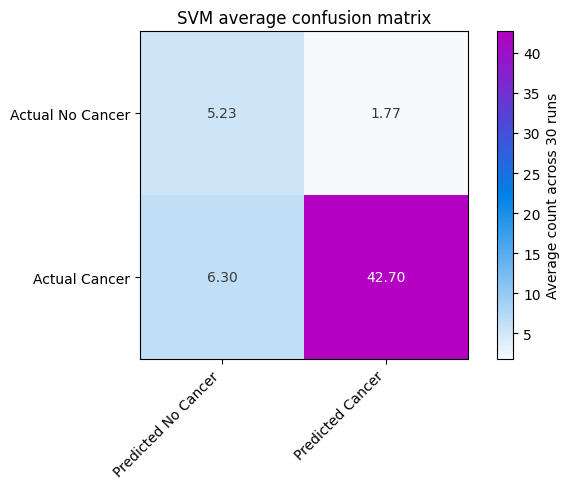


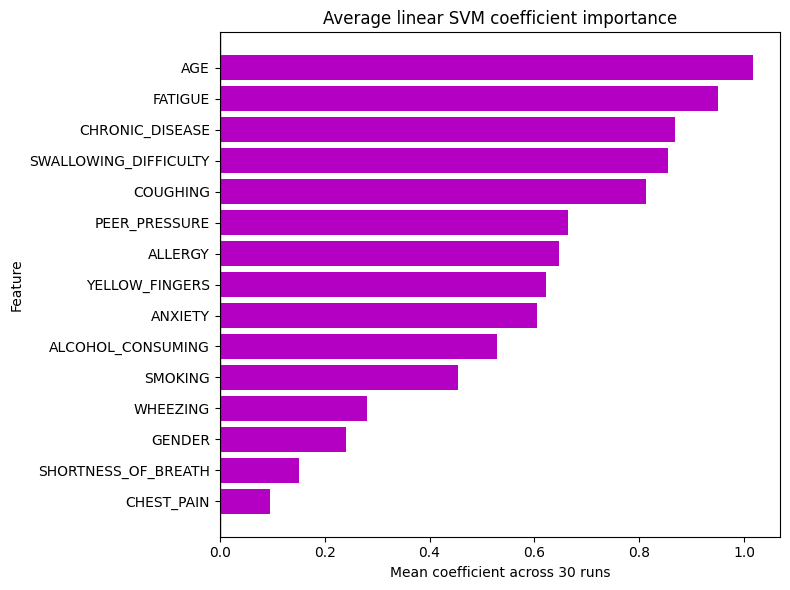

In [12]:
from time import perf_counter
from sklearn.svm import SVC

svm_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
svm_features = dataset_clean[svm_original_predictor_columns].copy()
svm_target = dataset_clean['LUNG_CANCER'].copy()

svm_age_features = ['AGE']
svm_other_numeric_features = [
    column_name for column_name in svm_original_predictor_columns if column_name not in svm_age_features
]
svm_transformed_feature_names = svm_age_features + svm_other_numeric_features

svm_preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            svm_age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            svm_other_numeric_features,
        ),
    ]
)

svm_model_kwargs = {
    'kernel': 'linear',
    'C': 1.0,
    'class_weight': 'balanced',
}
svm_random_seeds = list(range(30))

svm_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'kernel',
            'C',
            'class_weight',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            svm_model_kwargs['kernel'],
            f"{svm_model_kwargs['C']:.1f}",
            svm_model_kwargs['class_weight'],
            len(svm_random_seeds),
            '0.2',
            f"{svm_random_seeds[0]}-{svm_random_seeds[-1]}",
        ],
    }
)

svm_run_rows = []
svm_conf_matrices = []
svm_coefficient_rows = []

for svm_random_seed in svm_random_seeds:
    svm_X_train, svm_X_test, svm_y_train, svm_y_test = train_test_split(
        svm_features,
        svm_target,
        test_size=0.2,
        stratify=svm_target,
        random_state=svm_random_seed,
    )

    svm_pipeline = Pipeline(
        steps=[('preprocess', svm_preprocess), ('model', SVC(**svm_model_kwargs))]
    )
    svm_fit_start = perf_counter()
    svm_pipeline.fit(svm_X_train, svm_y_train)
    svm_training_time_seconds = perf_counter() - svm_fit_start

    svm_predictions = svm_pipeline.predict(svm_X_test)
    svm_decision_scores = svm_pipeline.decision_function(svm_X_test)
    svm_conf_matrices.append(
        confusion_matrix(svm_y_test, svm_predictions, labels=[0, 1])
    )
    svm_coefficient_rows.append(
        pd.Series(
            svm_pipeline.named_steps['model'].coef_[0],
            index=svm_transformed_feature_names,
        )
    )
    svm_run_rows.append(
        {
            'Random seed': svm_random_seed,
            'Accuracy': accuracy_score(svm_y_test, svm_predictions),
            'Precision': precision_score(svm_y_test, svm_predictions),
            'Recall': recall_score(svm_y_test, svm_predictions),
            'F2-score': fbeta_score(svm_y_test, svm_predictions, beta=2),
            'ROC-AUC': roc_auc_score(svm_y_test, svm_decision_scores),
            'Training time (seconds)': svm_training_time_seconds,
        }
    )

svm_run_metrics_df = pd.DataFrame(svm_run_rows)
svm_average_conf_matrix = np.mean(svm_conf_matrices, axis=0)
svm_coefficient_df = pd.DataFrame(svm_coefficient_rows)
svm_mean_coefficients = svm_coefficient_df.mean(axis=0)

svm_metrics_df = pd.DataFrame(
    {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F2-score', 'ROC-AUC', 'Training time (seconds)'],
        'Average value': [
            f"{svm_run_metrics_df['Accuracy'].mean():.4f}",
            f"{svm_run_metrics_df['Precision'].mean():.4f}",
            f"{svm_run_metrics_df['Recall'].mean():.4f}",
            f"{svm_run_metrics_df['F2-score'].mean():.4f}",
            f"{svm_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{svm_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

svm_confusion_matrix_df = pd.DataFrame(
    svm_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

svm_average_coefficients_df = (
    pd.DataFrame(
        {
            'Feature': svm_mean_coefficients.index,
            'Mean coefficient': svm_mean_coefficients.values,
        }
    )
    .assign(**{'Absolute mean coefficient': lambda df: df['Mean coefficient'].abs()})
    .sort_values('Absolute mean coefficient', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        svm_hyperparameter_df,
        'Table 8, Linear SVM hyperparameters and evaluation settings',
        width='58%',
    )))
    display(HTML(_render_centered_html_table(
        svm_metrics_df,
        'Table 9, Linear SVM average hold-out performance metrics across 30 runs',
        width='58%',
    )))
else:
    print(svm_hyperparameter_df.to_string(index=False))
    print(svm_metrics_df.to_string(index=False))
    print(svm_confusion_matrix_df.to_string(index=False))
    print(svm_average_coefficients_df.to_string(index=False))


def _display_centered_matplotlib_figure(figure, max_width='72%', caption=None):
    if HTML is not None and display is not None:
        import base64
        from io import BytesIO

        buffer = BytesIO()
        figure.savefig(
            buffer,
            format='png',
            bbox_inches='tight',
        )
        buffer.seek(0)
        figure_base64 = base64.b64encode(buffer.read()).decode('utf-8')
        plt.close(figure)
        display(HTML(
            "<div style='width: 100%; text-align: center;'>"
            f"<img src='data:image/png;base64,{figure_base64}' "
            f"style='display: block; margin: 0 auto; max-width: {max_width}; height: auto;'/>"
            f"<p style='text-align: center; margin-top: 8px; color: #000000;'><em>{caption}</em></p>" if caption else ""
            "</div>"
        ))
    else:
        plt.show()
        if caption:
            print(caption)


svm_confusion_fig, svm_confusion_ax = plt.subplots(figsize=(7, 5))
svm_confusion_image = svm_confusion_ax.imshow(svm_confusion_matrix_df.values, cmap=notebook_sequential_cmap)
svm_confusion_fig.colorbar(
    svm_confusion_image,
    ax=svm_confusion_ax,
    label='Average count across 30 runs',
)
svm_confusion_ax.set_xticks(range(len(svm_confusion_matrix_df.columns)))
svm_confusion_ax.set_xticklabels(
    svm_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
svm_confusion_ax.set_yticks(range(len(svm_confusion_matrix_df.index)))
svm_confusion_ax.set_yticklabels(svm_confusion_matrix_df.index)
svm_confusion_ax.set_title('SVM average confusion matrix')

svm_confusion_text_threshold = svm_confusion_matrix_df.values.max() / 2

for row_index in range(len(svm_confusion_matrix_df.index)):
    for column_index in range(len(svm_confusion_matrix_df.columns)):
        svm_confusion_ax.text(
            column_index,
            row_index,
            f"{svm_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color=notebook_matrix_text_color(
                svm_confusion_matrix_df.iloc[row_index, column_index],
                svm_confusion_text_threshold,
            ),
        )

svm_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    svm_confusion_fig,
    caption='Figure 4. SVM average confusion matrix across 30 stratified hold-out runs.',
)

svm_coefficient_plot_df = svm_average_coefficients_df.copy()
svm_coefficient_colors = [
    notebook_primary_color if coefficient > 0 else notebook_secondary_color
    for coefficient in svm_coefficient_plot_df['Mean coefficient']
]

svm_coefficient_fig, svm_coefficient_ax = plt.subplots(figsize=(8, 6))
svm_coefficient_ax.barh(
    svm_coefficient_plot_df['Feature'],
    svm_coefficient_plot_df['Mean coefficient'],
    color=svm_coefficient_colors,
)
svm_coefficient_ax.axvline(0, color=notebook_neutral_color, linewidth=1)
svm_coefficient_ax.set_title('Average linear SVM coefficient importance')
svm_coefficient_ax.set_xlabel('Mean coefficient across 30 runs')
svm_coefficient_ax.set_ylabel('Feature')
svm_coefficient_ax.invert_yaxis()
svm_coefficient_fig.tight_layout()
_display_centered_matplotlib_figure(
    svm_coefficient_fig,
    max_width='76%',
    caption='Figure 5. Average linear SVM coefficient importance across 30 stratified hold-out runs.',
)


## 3.3 Binary Tree

A binary decision tree was used as the first non-linear comparator on the cleaned original predictors. Unlike the linear SVM, the tree can capture simple interaction rules and threshold effects directly, which makes it useful for checking whether a small number of symptom combinations explain much of the signal in this dataset. Because the working dataset contains only 279 rows and is clearly imbalanced, the tree was given a moderate depth cap, a maximum leaf-node limit, class balancing, and the same 30 stratified 80/20 hold-out reruns so the reported results are not driven by one favourable split.

### 3.3.1 Hyperparameters

The binary tree was configured to stay interpretable rather than aggressively tuned. A depth limit of five levels and a maximum of 24 leaf nodes keep the fitted structure readable while still allowing more branching than the earlier shallow version.

### 3.3.2 Binary Tree Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the plotted tree gives one representative fitted structure from the rerun whose F2-score was closest to the 30-run mean.

SETTING,VALUE
criterion,entropy
max_depth,5
max_leaf_nodes,24
class_weight,balanced
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.8143
Precision,0.9480
Recall,0.8340
F2-score,0.8540
ROC-AUC,0.7673
Training time (seconds),0.0100



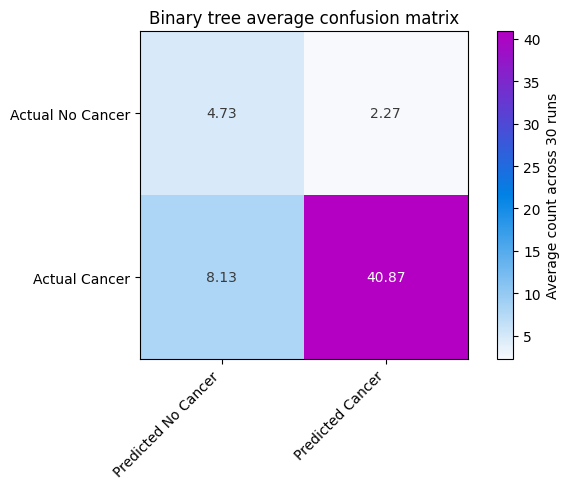


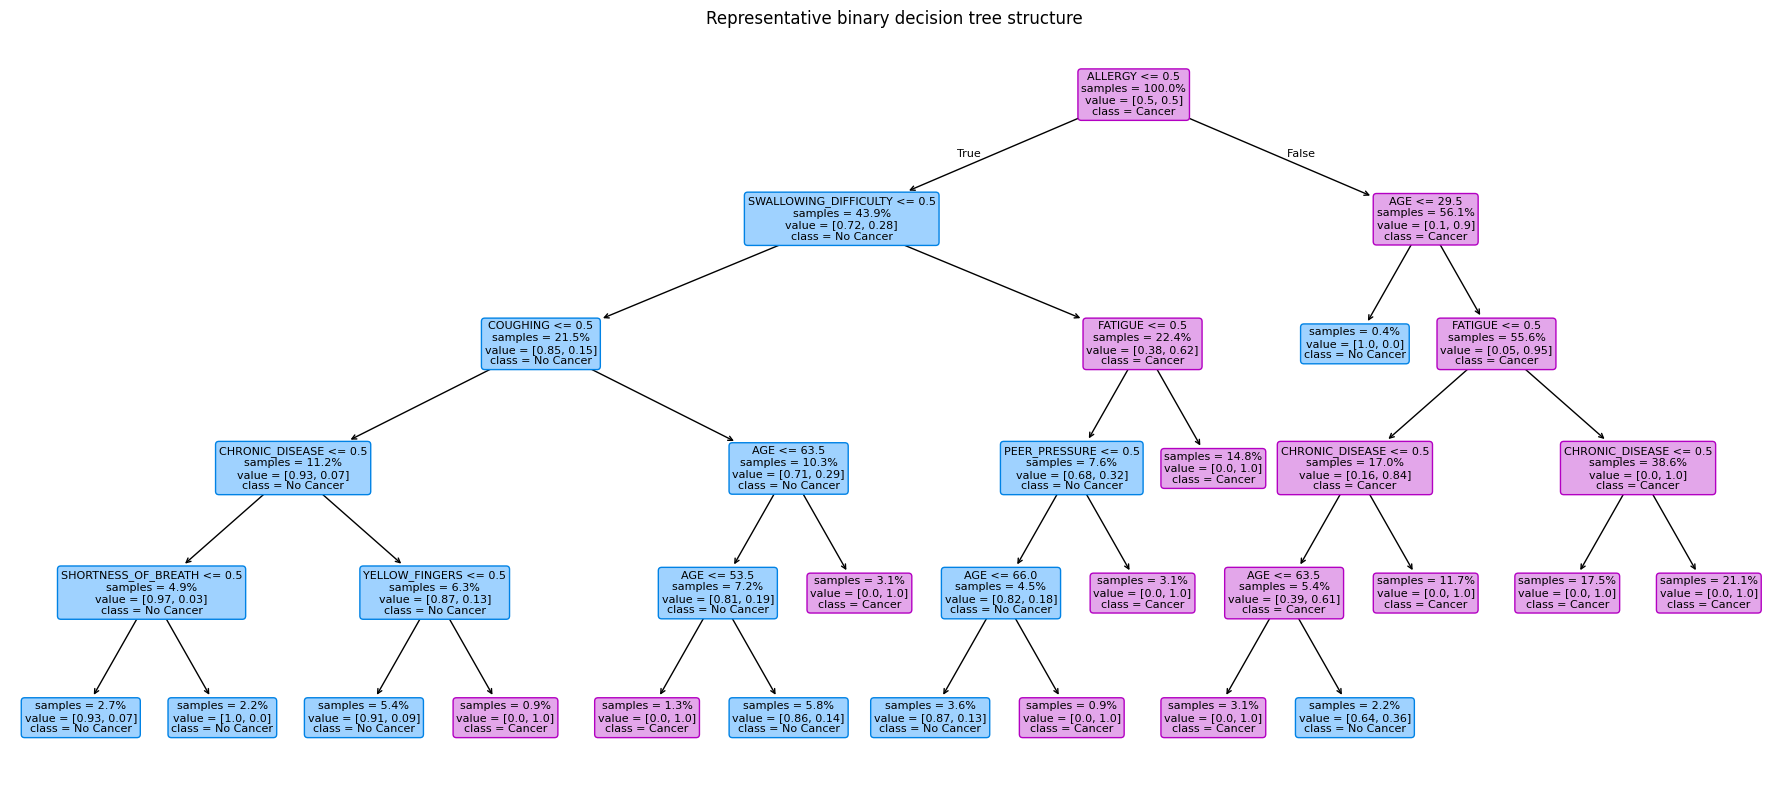

In [13]:
from time import perf_counter
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
tree_features = dataset_clean[tree_original_predictor_columns].copy()
tree_target = dataset_clean['LUNG_CANCER'].copy()
tree_feature_names = tree_original_predictor_columns.copy()

tree_preprocess = ColumnTransformer(
    transformers=[
        (
            'raw_numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]
            ),
            tree_original_predictor_columns,
        ),
    ]
)

tree_model_kwargs = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_leaf_nodes': 24,
    'class_weight': 'balanced',
}
tree_random_seeds = list(range(30))

tree_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'criterion',
            'max_depth',
            'max_leaf_nodes',
            'class_weight',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            tree_model_kwargs['criterion'],
            str(tree_model_kwargs['max_depth']),
            str(tree_model_kwargs['max_leaf_nodes']),
            tree_model_kwargs['class_weight'],
            len(tree_random_seeds),
            '0.2',
            f"{tree_random_seeds[0]}-{tree_random_seeds[-1]}",
        ],
    }
)

tree_run_rows = []
tree_conf_matrices = []

for tree_random_seed in tree_random_seeds:
    tree_X_train, tree_X_test, tree_y_train, tree_y_test = train_test_split(
        tree_features,
        tree_target,
        test_size=0.2,
        stratify=tree_target,
        random_state=tree_random_seed,
    )

    tree_pipeline = Pipeline(
        steps=[
            ('preprocess', tree_preprocess),
            (
                'model',
                DecisionTreeClassifier(
                    **tree_model_kwargs,
                    random_state=tree_random_seed,
                ),
            ),
        ]
    )
    tree_fit_start = perf_counter()
    tree_pipeline.fit(tree_X_train, tree_y_train)
    tree_training_time_seconds = perf_counter() - tree_fit_start

    tree_predictions = tree_pipeline.predict(tree_X_test)
    tree_probabilities = tree_pipeline.predict_proba(tree_X_test)[:, 1]
    tree_conf_matrices.append(
        confusion_matrix(tree_y_test, tree_predictions, labels=[0, 1])
    )
    tree_run_rows.append(
        {
            'Random seed': tree_random_seed,
            'Accuracy': accuracy_score(tree_y_test, tree_predictions),
            'Precision': precision_score(
                tree_y_test,
                tree_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(tree_y_test, tree_predictions),
            'F2-score': fbeta_score(tree_y_test, tree_predictions, beta=2),
            'ROC-AUC': roc_auc_score(tree_y_test, tree_probabilities),
            'Training time (seconds)': tree_training_time_seconds,
        }
    )

tree_run_metrics_df = pd.DataFrame(tree_run_rows)
tree_average_conf_matrix = np.mean(tree_conf_matrices, axis=0)

tree_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{tree_run_metrics_df['Accuracy'].mean():.4f}",
            f"{tree_run_metrics_df['Precision'].mean():.4f}",
            f"{tree_run_metrics_df['Recall'].mean():.4f}",
            f"{tree_run_metrics_df['F2-score'].mean():.4f}",
            f"{tree_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{tree_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

tree_confusion_matrix_df = pd.DataFrame(
    tree_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

tree_reference_seed = int(
    tree_run_metrics_df.loc[
        (tree_run_metrics_df['F2-score'] - tree_run_metrics_df['F2-score'].mean())
        .abs()
        .idxmin(),
        'Random seed',
    ]
)
tree_reference_X_train, tree_reference_X_test, tree_reference_y_train, tree_reference_y_test = train_test_split(
    tree_features,
    tree_target,
    test_size=0.2,
    stratify=tree_target,
    random_state=tree_reference_seed,
)
tree_reference_pipeline = Pipeline(
    steps=[
        ('preprocess', tree_preprocess),
        (
            'model',
            DecisionTreeClassifier(
                **tree_model_kwargs,
                random_state=tree_reference_seed,
            ),
        ),
    ]
)
tree_reference_pipeline.fit(tree_reference_X_train, tree_reference_y_train)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        tree_hyperparameter_df,
        'Table 10, Binary tree hyperparameters and evaluation settings',
        width='58%',
    )))
    display(HTML(_render_centered_html_table(
        tree_metrics_df,
        'Table 11, Binary tree average hold-out performance metrics across 30 runs',
        width='58%',
    )))
else:
    print(tree_hyperparameter_df.to_string(index=False))
    print(tree_metrics_df.to_string(index=False))
    print(tree_confusion_matrix_df.to_string(index=False))

if '_display_centered_matplotlib_figure' not in globals():
    def _display_centered_matplotlib_figure(figure, max_width='72%', caption=None):
        if HTML is not None and display is not None:
            import base64
            from io import BytesIO

            buffer = BytesIO()
            figure.savefig(
                buffer,
                format='png',
                bbox_inches='tight',
            )
            buffer.seek(0)
            figure_base64 = base64.b64encode(buffer.read()).decode('utf-8')
            plt.close(figure)
            display(HTML(
                "<div style='width: 100%; text-align: center;'>"
                f"<img src='data:image/png;base64,{figure_base64}' "
                f"style='display: block; margin: 0 auto; max-width: {max_width}; height: auto;'/>"
                f"<p style='text-align: center; margin-top: 8px; color: #000000;'><em>{caption}</em></p>" if caption else ""
                "</div>"
            ))
        else:
            plt.show()
            if caption:
                print(caption)

tree_confusion_fig, tree_confusion_ax = plt.subplots(figsize=(7, 5))
tree_confusion_image = tree_confusion_ax.imshow(
    tree_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
tree_confusion_fig.colorbar(
    tree_confusion_image,
    ax=tree_confusion_ax,
    label='Average count across 30 runs',
)
tree_confusion_ax.set_xticks(range(len(tree_confusion_matrix_df.columns)))
tree_confusion_ax.set_xticklabels(
    tree_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
tree_confusion_ax.set_yticks(range(len(tree_confusion_matrix_df.index)))
tree_confusion_ax.set_yticklabels(tree_confusion_matrix_df.index)
tree_confusion_ax.set_title('Binary tree average confusion matrix')

tree_confusion_text_threshold = tree_confusion_matrix_df.values.max() / 2

for row_index in range(len(tree_confusion_matrix_df.index)):
    for column_index in range(len(tree_confusion_matrix_df.columns)):
        tree_confusion_ax.text(
            column_index,
            row_index,
            f"{tree_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color=notebook_matrix_text_color(
                tree_confusion_matrix_df.iloc[row_index, column_index],
                tree_confusion_text_threshold,
            ),
        )

tree_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    tree_confusion_fig,
    caption='Figure 6. Binary tree average confusion matrix across 30 stratified hold-out runs.',
)

tree_plot_fig, tree_plot_ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_reference_pipeline.named_steps['model'],
    feature_names=tree_feature_names,
    class_names=['No Cancer', 'Cancer'],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    precision=2,
    fontsize=8,
    ax=tree_plot_ax,
)
for annotation in tree_plot_ax.texts:
    bbox = annotation.get_bbox_patch()
    if bbox is None:
        continue
    node_text = annotation.get_text()
    if 'class = No Cancer' in node_text:
        bbox.set_facecolor(notebook_secondary_light)
        bbox.set_edgecolor(notebook_secondary_color)
    elif 'class = Cancer' in node_text:
        bbox.set_facecolor(notebook_primary_light)
        bbox.set_edgecolor(notebook_primary_color)
    else:
        bbox.set_facecolor('#F7F9FC')
        bbox.set_edgecolor(notebook_neutral_color)

tree_plot_ax.set_title('Representative binary decision tree structure')
tree_plot_fig.tight_layout()
_display_centered_matplotlib_figure(
    tree_plot_fig,
    max_width='94%',
    caption=(
        'Figure 7. Representative binary decision tree fitted on the stratified train split '
        f'for seed {tree_reference_seed}, chosen because its F2-score was closest to the 30-run mean.'
    ),
)


## 3.4 Random Forest

A random forest was used to test whether an ensemble of decorrelated decision trees improves on the single-tree baseline while still using only the cleaned original predictors. This model is a useful contrast because bagging reduces the instability of one decision tree and can recover non-linear interactions without requiring the later engineered batch features. As in the earlier section-3 experiments, the model is evaluated across 30 stratified 80/20 hold-out reruns so the reported results reflect average behaviour rather than one favourable split.

### 3.4.1 Hyperparameters

The forest was configured with balanced class weights, the standard `sqrt` feature-subsampling rule, and a small leaf-size constraint while allowing slightly deeper trees than the initial baseline configuration. That keeps the ensemble more stable than a single tree but still flexible enough to recover interactions and improve recall on this small dataset.

### 3.4.2 Random Forest Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the feature-importance chart shows the average impurity-based importance across the same reruns.

SETTING,VALUE
n_estimators,500
max_depth,8
min_samples_leaf,2
max_features,sqrt
class_weight,balanced
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.8982
Precision,0.9399
Recall,0.9449
F2-score,0.9437
ROC-AUC,0.9272
Training time (seconds),0.6552



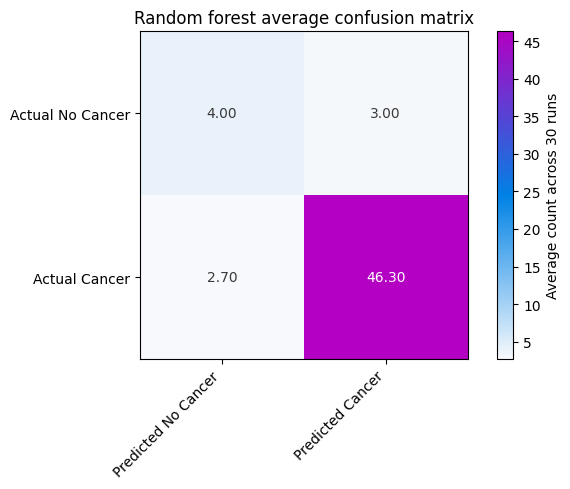


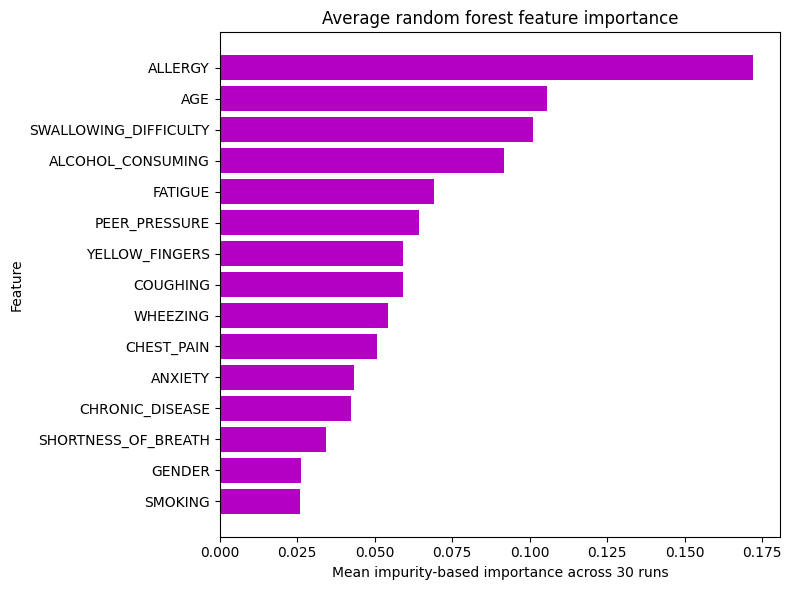

In [14]:
from time import perf_counter

rf_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
rf_features = dataset_clean[rf_original_predictor_columns].copy()
rf_target = dataset_clean['LUNG_CANCER'].copy()
rf_feature_names = rf_original_predictor_columns.copy()

rf_preprocess = ColumnTransformer(
    transformers=[
        (
            'raw_numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                ]
            ),
            rf_original_predictor_columns,
        ),
    ]
)

rf_model_kwargs = {
    'n_estimators': 500,
    'max_depth': 8,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
}
rf_random_seeds = list(range(30))

rf_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'n_estimators',
            'max_depth',
            'min_samples_leaf',
            'max_features',
            'class_weight',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            str(rf_model_kwargs['n_estimators']),
            str(rf_model_kwargs['max_depth']),
            str(rf_model_kwargs['min_samples_leaf']),
            rf_model_kwargs['max_features'],
            rf_model_kwargs['class_weight'],
            len(rf_random_seeds),
            '0.2',
            f"{rf_random_seeds[0]}-{rf_random_seeds[-1]}",
        ],
    }
)

rf_run_rows = []
rf_conf_matrices = []
rf_feature_importance_rows = []

for rf_random_seed in rf_random_seeds:
    rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
        rf_features,
        rf_target,
        test_size=0.2,
        stratify=rf_target,
        random_state=rf_random_seed,
    )

    rf_pipeline = Pipeline(
        steps=[
            ('preprocess', rf_preprocess),
            (
                'model',
                RandomForestClassifier(
                    **rf_model_kwargs,
                    random_state=rf_random_seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    rf_fit_start = perf_counter()
    rf_pipeline.fit(rf_X_train, rf_y_train)
    rf_training_time_seconds = perf_counter() - rf_fit_start

    rf_predictions = rf_pipeline.predict(rf_X_test)
    rf_probabilities = rf_pipeline.predict_proba(rf_X_test)[:, 1]
    rf_conf_matrices.append(
        confusion_matrix(rf_y_test, rf_predictions, labels=[0, 1])
    )
    rf_feature_importance_rows.append(
        pd.Series(
            rf_pipeline.named_steps['model'].feature_importances_,
            index=rf_feature_names,
        )
    )
    rf_run_rows.append(
        {
            'Random seed': rf_random_seed,
            'Accuracy': accuracy_score(rf_y_test, rf_predictions),
            'Precision': precision_score(
                rf_y_test,
                rf_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(rf_y_test, rf_predictions),
            'F2-score': fbeta_score(rf_y_test, rf_predictions, beta=2),
            'ROC-AUC': roc_auc_score(rf_y_test, rf_probabilities),
            'Training time (seconds)': rf_training_time_seconds,
        }
    )

rf_run_metrics_df = pd.DataFrame(rf_run_rows)
rf_average_conf_matrix = np.mean(rf_conf_matrices, axis=0)
rf_feature_importance_df = pd.DataFrame(rf_feature_importance_rows)
rf_mean_feature_importance = rf_feature_importance_df.mean(axis=0)

rf_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{rf_run_metrics_df['Accuracy'].mean():.4f}",
            f"{rf_run_metrics_df['Precision'].mean():.4f}",
            f"{rf_run_metrics_df['Recall'].mean():.4f}",
            f"{rf_run_metrics_df['F2-score'].mean():.4f}",
            f"{rf_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{rf_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

rf_confusion_matrix_df = pd.DataFrame(
    rf_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

rf_average_feature_importance_df = (
    pd.DataFrame(
        {
            'Feature': rf_mean_feature_importance.index,
            'Mean importance': rf_mean_feature_importance.values,
        }
    )
    .sort_values('Mean importance', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        rf_hyperparameter_df,
        'Table 12, Random forest hyperparameters and evaluation settings',
        width='60%',
    )))
    display(HTML(_render_centered_html_table(
        rf_metrics_df,
        'Table 13, Random forest average hold-out performance metrics across 30 runs',
        width='60%',
    )))
else:
    print(rf_hyperparameter_df.to_string(index=False))
    print(rf_metrics_df.to_string(index=False))
    print(rf_confusion_matrix_df.to_string(index=False))
    print(rf_average_feature_importance_df.to_string(index=False))

rf_confusion_fig, rf_confusion_ax = plt.subplots(figsize=(7, 5))
rf_confusion_image = rf_confusion_ax.imshow(
    rf_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
rf_confusion_fig.colorbar(
    rf_confusion_image,
    ax=rf_confusion_ax,
    label='Average count across 30 runs',
)
rf_confusion_ax.set_xticks(range(len(rf_confusion_matrix_df.columns)))
rf_confusion_ax.set_xticklabels(
    rf_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
rf_confusion_ax.set_yticks(range(len(rf_confusion_matrix_df.index)))
rf_confusion_ax.set_yticklabels(rf_confusion_matrix_df.index)
rf_confusion_ax.set_title('Random forest average confusion matrix')

rf_confusion_text_threshold = rf_confusion_matrix_df.values.max() / 2

for row_index in range(len(rf_confusion_matrix_df.index)):
    for column_index in range(len(rf_confusion_matrix_df.columns)):
        rf_confusion_ax.text(
            column_index,
            row_index,
            f"{rf_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color=notebook_matrix_text_color(
                rf_confusion_matrix_df.iloc[row_index, column_index],
                rf_confusion_text_threshold,
            ),
        )

rf_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    rf_confusion_fig,
    caption='Figure 8. Random forest average confusion matrix across 30 stratified hold-out runs.',
)

rf_importance_plot_df = rf_average_feature_importance_df.copy()
rf_importance_fig, rf_importance_ax = plt.subplots(figsize=(8, 6))
rf_importance_ax.barh(
    rf_importance_plot_df['Feature'],
    rf_importance_plot_df['Mean importance'],
    color=notebook_primary_color,
)
rf_importance_ax.set_title('Average random forest feature importance')
rf_importance_ax.set_xlabel('Mean impurity-based importance across 30 runs')
rf_importance_ax.set_ylabel('Feature')
rf_importance_ax.invert_yaxis()
rf_importance_fig.tight_layout()
_display_centered_matplotlib_figure(
    rf_importance_fig,
    max_width='78%',
    caption='Figure 9. Average random forest feature importance across 30 stratified hold-out runs.',
)


## 3.5 ANN

A small artificial neural network was included as a feed-forward multilayer perceptron (MLP) classifier on the cleaned original predictors. For this tabular dataset, the appropriate ANN type is a multilayer perceptron rather than an image or sequence model, because the inputs are structured patient attributes rather than pixels, time steps, or text. The network was kept deliberately small so it could test whether learned non-linear feature combinations add value without turning section 3 into a high-capacity deep-learning exercise on only 279 rows.

### 3.5.1 Hyperparameters

The ANN used a two-hidden-layer multilayer perceptron (MLP) with regularisation, scaled inputs, and balanced training sample weights. This is a sensible compromise for a small imbalanced tabular dataset: large enough to learn interactions, but still constrained enough to reduce overfitting risk.

### 3.5.2 ANN Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the loss plot shows one representative training-loss trajectory from the rerun whose F2-score was closest to the 30-run mean.

SETTING,VALUE
hidden_layer_sizes,"(16, 8)"
activation,relu
solver,adam
alpha,0.0010
batch_size,32
learning_rate_init,0.0010
max_iter,500
early_stopping,True
n_iter_no_change,20
training sample weighting,balanced by compute_sample_weight()


METRIC,AVERAGE VALUE
Accuracy,0.8506
Precision,0.9609
Recall,0.8660
F2-score,0.8823
ROC-AUC,0.8910
Training time (seconds),0.1384



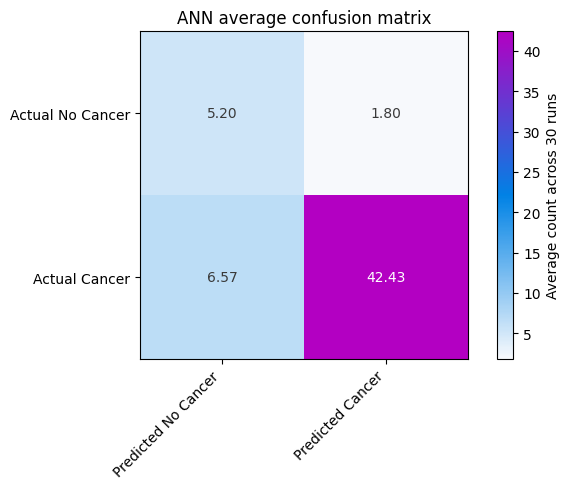


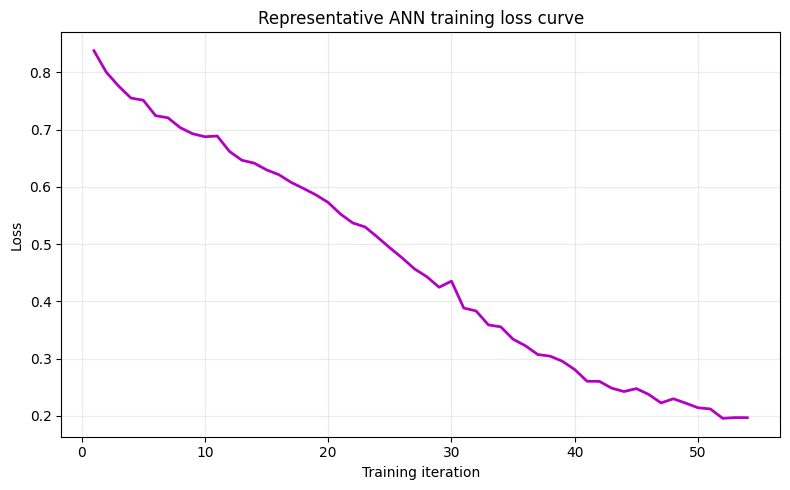

In [15]:
from time import perf_counter
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

ann_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
ann_features = dataset_clean[ann_original_predictor_columns].copy()
ann_target = dataset_clean['LUNG_CANCER'].copy()

ann_age_features = ['AGE']
ann_other_numeric_features = [
    column_name for column_name in ann_original_predictor_columns if column_name not in ann_age_features
]

ann_preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            ann_age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            ann_other_numeric_features,
        ),
    ]
)

ann_model_kwargs = {
    'hidden_layer_sizes': (16, 8),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.001,
    'batch_size': 32,
    'learning_rate_init': 0.001,
    'max_iter': 500,
    'early_stopping': True,
    'n_iter_no_change': 20,
}
ann_random_seeds = list(range(30))

ann_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'hidden_layer_sizes',
            'activation',
            'solver',
            'alpha',
            'batch_size',
            'learning_rate_init',
            'max_iter',
            'early_stopping',
            'n_iter_no_change',
            'training sample weighting',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            str(ann_model_kwargs['hidden_layer_sizes']),
            ann_model_kwargs['activation'],
            ann_model_kwargs['solver'],
            f"{ann_model_kwargs['alpha']:.4f}",
            str(ann_model_kwargs['batch_size']),
            f"{ann_model_kwargs['learning_rate_init']:.4f}",
            str(ann_model_kwargs['max_iter']),
            str(ann_model_kwargs['early_stopping']),
            str(ann_model_kwargs['n_iter_no_change']),
            'balanced by compute_sample_weight()',
            len(ann_random_seeds),
            '0.2',
            f"{ann_random_seeds[0]}-{ann_random_seeds[-1]}",
        ],
    }
)

ann_run_rows = []
ann_conf_matrices = []

for ann_random_seed in ann_random_seeds:
    ann_X_train, ann_X_test, ann_y_train, ann_y_test = train_test_split(
        ann_features,
        ann_target,
        test_size=0.2,
        stratify=ann_target,
        random_state=ann_random_seed,
    )

    ann_pipeline = Pipeline(
        steps=[
            ('preprocess', ann_preprocess),
            (
                'model',
                MLPClassifier(
                    **ann_model_kwargs,
                    random_state=ann_random_seed,
                ),
            ),
        ]
    )
    ann_sample_weight = compute_sample_weight(
        class_weight='balanced',
        y=ann_y_train,
    )
    ann_fit_start = perf_counter()
    ann_pipeline.fit(
        ann_X_train,
        ann_y_train,
        model__sample_weight=ann_sample_weight,
    )
    ann_training_time_seconds = perf_counter() - ann_fit_start

    ann_predictions = ann_pipeline.predict(ann_X_test)
    ann_probabilities = ann_pipeline.predict_proba(ann_X_test)[:, 1]
    ann_conf_matrices.append(
        confusion_matrix(ann_y_test, ann_predictions, labels=[0, 1])
    )
    ann_run_rows.append(
        {
            'Random seed': ann_random_seed,
            'Accuracy': accuracy_score(ann_y_test, ann_predictions),
            'Precision': precision_score(
                ann_y_test,
                ann_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(ann_y_test, ann_predictions),
            'F2-score': fbeta_score(ann_y_test, ann_predictions, beta=2),
            'ROC-AUC': roc_auc_score(ann_y_test, ann_probabilities),
            'Training time (seconds)': ann_training_time_seconds,
        }
    )

ann_run_metrics_df = pd.DataFrame(ann_run_rows)
ann_average_conf_matrix = np.mean(ann_conf_matrices, axis=0)

ann_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{ann_run_metrics_df['Accuracy'].mean():.4f}",
            f"{ann_run_metrics_df['Precision'].mean():.4f}",
            f"{ann_run_metrics_df['Recall'].mean():.4f}",
            f"{ann_run_metrics_df['F2-score'].mean():.4f}",
            f"{ann_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{ann_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

ann_confusion_matrix_df = pd.DataFrame(
    ann_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

ann_reference_seed = int(
    ann_run_metrics_df.loc[
        (ann_run_metrics_df['F2-score'] - ann_run_metrics_df['F2-score'].mean())
        .abs()
        .idxmin(),
        'Random seed',
    ]
)
ann_reference_X_train, ann_reference_X_test, ann_reference_y_train, ann_reference_y_test = train_test_split(
    ann_features,
    ann_target,
    test_size=0.2,
    stratify=ann_target,
    random_state=ann_reference_seed,
)
ann_reference_pipeline = Pipeline(
    steps=[
        ('preprocess', ann_preprocess),
        (
            'model',
            MLPClassifier(
                **ann_model_kwargs,
                random_state=ann_reference_seed,
            ),
        ),
    ]
)
ann_reference_sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=ann_reference_y_train,
)
ann_reference_pipeline.fit(
    ann_reference_X_train,
    ann_reference_y_train,
    model__sample_weight=ann_reference_sample_weight,
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        ann_hyperparameter_df,
        'Table 14, ANN hyperparameters and evaluation settings',
        width='66%',
    )))
    display(HTML(_render_centered_html_table(
        ann_metrics_df,
        'Table 15, ANN average hold-out performance metrics across 30 runs',
        width='60%',
    )))
else:
    print(ann_hyperparameter_df.to_string(index=False))
    print(ann_metrics_df.to_string(index=False))
    print(ann_confusion_matrix_df.to_string(index=False))

ann_confusion_fig, ann_confusion_ax = plt.subplots(figsize=(7, 5))
ann_confusion_image = ann_confusion_ax.imshow(
    ann_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
ann_confusion_fig.colorbar(
    ann_confusion_image,
    ax=ann_confusion_ax,
    label='Average count across 30 runs',
)
ann_confusion_ax.set_xticks(range(len(ann_confusion_matrix_df.columns)))
ann_confusion_ax.set_xticklabels(
    ann_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
ann_confusion_ax.set_yticks(range(len(ann_confusion_matrix_df.index)))
ann_confusion_ax.set_yticklabels(ann_confusion_matrix_df.index)
ann_confusion_ax.set_title('ANN average confusion matrix')

ann_confusion_text_threshold = ann_confusion_matrix_df.values.max() / 2

for row_index in range(len(ann_confusion_matrix_df.index)):
    for column_index in range(len(ann_confusion_matrix_df.columns)):
        ann_confusion_ax.text(
            column_index,
            row_index,
            f"{ann_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color=notebook_matrix_text_color(
                ann_confusion_matrix_df.iloc[row_index, column_index],
                ann_confusion_text_threshold,
            ),
        )

ann_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    ann_confusion_fig,
    caption='Figure 10. ANN average confusion matrix across 30 stratified hold-out runs.',
)

ann_loss_curve = ann_reference_pipeline.named_steps['model'].loss_curve_
ann_loss_fig, ann_loss_ax = plt.subplots(figsize=(8, 5))
ann_loss_ax.plot(
    range(1, len(ann_loss_curve) + 1),
    ann_loss_curve,
    color=notebook_primary_color,
    linewidth=2,
)
ann_loss_ax.set_title('Representative ANN training loss curve')
ann_loss_ax.set_xlabel('Training iteration')
ann_loss_ax.set_ylabel('Loss')
ann_loss_ax.grid(True, alpha=0.25)
ann_loss_fig.tight_layout()
_display_centered_matplotlib_figure(
    ann_loss_fig,
    max_width='78%',
    caption=(
        'Figure 11. Representative ANN training loss curve for the stratified train split '
        f'with seed {ann_reference_seed}, chosen because its F2-score was closest to the 30-run mean.'
    ),
)


## 3.6 Logistic Regression

A logistic regression baseline was included because it is a transparent linear probabilistic classifier for binary tabular data. On this dataset, the model forms a weighted linear score from the cleaned original predictors and then applies the sigmoid function to convert that score into an estimated probability of the cancer class. This makes it a useful check on whether the main signal is mostly additive rather than depending on complex interaction rules. As in the earlier section-3 experiments, the model is evaluated across 30 stratified 80/20 hold-out reruns so the reported results reflect average behaviour instead of one favourable split.

### 3.6.1 Hyperparameters

The logistic regression model used L2 regularisation, balanced class weighting, and leakage-safe scaling inside the pipeline. A brief three-setting check over the regularisation strength (`C = 0.5`, `1.0`, and `2.0`) kept the rest of the setup fixed and selected `C=2.0` because it produced the highest mean F2-score. The `lbfgs` optimiser remains a reliable choice for a small dense binary problem like this one, while `max_iter=2000` leaves enough room for convergence without making the model more flexible.

### 3.6.2 Logistic Regression Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the coefficient chart shows the average fitted logistic-regression coefficients across the same reruns. Positive coefficients increase the log-odds of the cancer class after preprocessing, while negative coefficients reduce them.

SETTING,VALUE
penalty,l2
C,2.0
solver,lbfgs
max_iter,2000
class_weight,balanced
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.8589
Precision,0.9600
Recall,0.8762
F2-score,0.8912
ROC-AUC,0.9199
Training time (seconds),0.0167



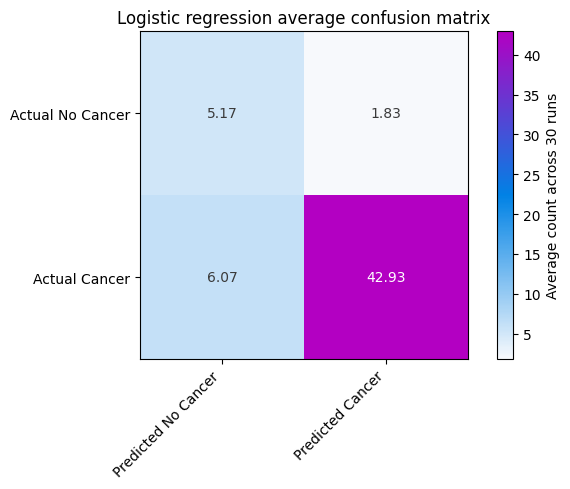


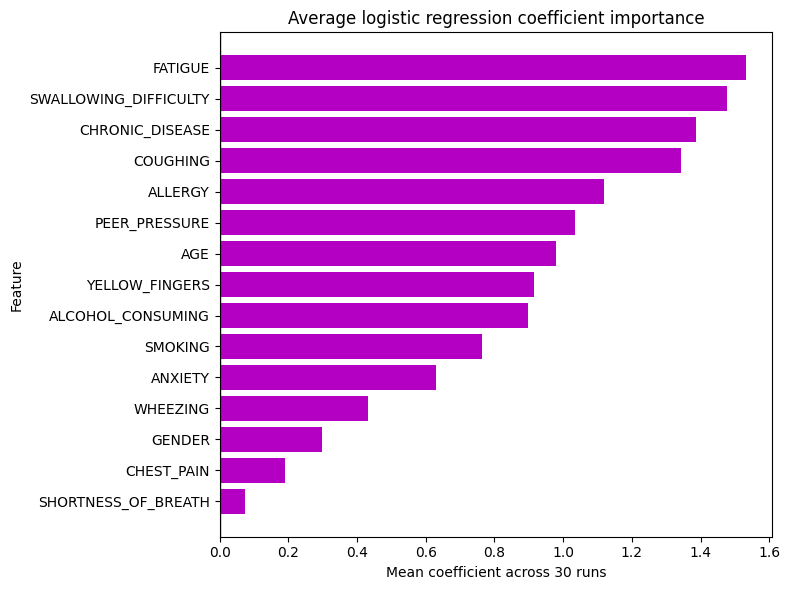

In [16]:
from time import perf_counter

logreg_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
logreg_features = dataset_clean[logreg_original_predictor_columns].copy()
logreg_target = dataset_clean['LUNG_CANCER'].copy()

logreg_age_features = ['AGE']
logreg_other_numeric_features = [
    column_name for column_name in logreg_original_predictor_columns if column_name not in logreg_age_features
]
logreg_transformed_feature_names = logreg_age_features + logreg_other_numeric_features

logreg_preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            logreg_age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            logreg_other_numeric_features,
        ),
    ]
)

logreg_model_kwargs = {
    'penalty': 'l2',
    'C': 2.0,
    'solver': 'lbfgs',
    'max_iter': 2000,
    'class_weight': 'balanced',
}
logreg_random_seeds = list(range(30))

logreg_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'penalty',
            'C',
            'solver',
            'max_iter',
            'class_weight',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            logreg_model_kwargs['penalty'],
            f"{logreg_model_kwargs['C']:.1f}",
            logreg_model_kwargs['solver'],
            str(logreg_model_kwargs['max_iter']),
            logreg_model_kwargs['class_weight'],
            len(logreg_random_seeds),
            '0.2',
            f"{logreg_random_seeds[0]}-{logreg_random_seeds[-1]}",
        ],
    }
)

logreg_run_rows = []
logreg_conf_matrices = []
logreg_coefficient_rows = []

for logreg_random_seed in logreg_random_seeds:
    logreg_X_train, logreg_X_test, logreg_y_train, logreg_y_test = train_test_split(
        logreg_features,
        logreg_target,
        test_size=0.2,
        stratify=logreg_target,
        random_state=logreg_random_seed,
    )

    logreg_pipeline = Pipeline(
        steps=[
            ('preprocess', logreg_preprocess),
            (
                'model',
                LogisticRegression(
                    **logreg_model_kwargs,
                    random_state=logreg_random_seed,
                ),
            ),
        ]
    )
    logreg_fit_start = perf_counter()
    logreg_pipeline.fit(logreg_X_train, logreg_y_train)
    logreg_training_time_seconds = perf_counter() - logreg_fit_start

    logreg_predictions = logreg_pipeline.predict(logreg_X_test)
    logreg_probabilities = logreg_pipeline.predict_proba(logreg_X_test)[:, 1]
    logreg_conf_matrices.append(
        confusion_matrix(logreg_y_test, logreg_predictions, labels=[0, 1])
    )
    logreg_coefficient_rows.append(
        pd.Series(
            logreg_pipeline.named_steps['model'].coef_[0],
            index=logreg_transformed_feature_names,
        )
    )
    logreg_run_rows.append(
        {
            'Random seed': logreg_random_seed,
            'Accuracy': accuracy_score(logreg_y_test, logreg_predictions),
            'Precision': precision_score(
                logreg_y_test,
                logreg_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(logreg_y_test, logreg_predictions),
            'F2-score': fbeta_score(logreg_y_test, logreg_predictions, beta=2),
            'ROC-AUC': roc_auc_score(logreg_y_test, logreg_probabilities),
            'Training time (seconds)': logreg_training_time_seconds,
        }
    )

logreg_run_metrics_df = pd.DataFrame(logreg_run_rows)
logreg_average_conf_matrix = np.mean(logreg_conf_matrices, axis=0)
logreg_coefficient_df = pd.DataFrame(logreg_coefficient_rows)
logreg_mean_coefficients = logreg_coefficient_df.mean(axis=0)

logreg_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{logreg_run_metrics_df['Accuracy'].mean():.4f}",
            f"{logreg_run_metrics_df['Precision'].mean():.4f}",
            f"{logreg_run_metrics_df['Recall'].mean():.4f}",
            f"{logreg_run_metrics_df['F2-score'].mean():.4f}",
            f"{logreg_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{logreg_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

logreg_confusion_matrix_df = pd.DataFrame(
    logreg_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

logreg_average_coefficients_df = (
    pd.DataFrame(
        {
            'Feature': logreg_mean_coefficients.index,
            'Mean coefficient': logreg_mean_coefficients.values,
        }
    )
    .assign(**{'Absolute mean coefficient': lambda df: df['Mean coefficient'].abs()})
    .sort_values('Absolute mean coefficient', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        logreg_hyperparameter_df,
        'Table 16, Logistic regression hyperparameters and evaluation settings',
        width='60%',
    )))
    display(HTML(_render_centered_html_table(
        logreg_metrics_df,
        'Table 17, Logistic regression average hold-out performance metrics across 30 runs',
        width='60%',
    )))
else:
    print(logreg_hyperparameter_df.to_string(index=False))
    print(logreg_metrics_df.to_string(index=False))
    print(logreg_confusion_matrix_df.to_string(index=False))
    print(logreg_average_coefficients_df.to_string(index=False))

logreg_confusion_fig, logreg_confusion_ax = plt.subplots(figsize=(7, 5))
logreg_confusion_image = logreg_confusion_ax.imshow(
    logreg_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
logreg_confusion_fig.colorbar(
    logreg_confusion_image,
    ax=logreg_confusion_ax,
    label='Average count across 30 runs',
)
logreg_confusion_ax.set_xticks(range(len(logreg_confusion_matrix_df.columns)))
logreg_confusion_ax.set_xticklabels(
    logreg_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
logreg_confusion_ax.set_yticks(range(len(logreg_confusion_matrix_df.index)))
logreg_confusion_ax.set_yticklabels(logreg_confusion_matrix_df.index)
logreg_confusion_ax.set_title('Logistic regression average confusion matrix')

logreg_confusion_text_threshold = logreg_confusion_matrix_df.values.max() / 2

for row_index in range(len(logreg_confusion_matrix_df.index)):
    for column_index in range(len(logreg_confusion_matrix_df.columns)):
        logreg_confusion_ax.text(
            column_index,
            row_index,
            f"{logreg_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color=notebook_matrix_text_color(
                logreg_confusion_matrix_df.iloc[row_index, column_index],
                logreg_confusion_text_threshold,
            ),
        )

logreg_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    logreg_confusion_fig,
    caption='Figure 12. Logistic regression average confusion matrix across 30 stratified hold-out runs.',
)

logreg_coefficient_plot_df = logreg_average_coefficients_df.copy()
logreg_coefficient_colors = [
    notebook_primary_color if coefficient > 0 else notebook_secondary_color
    for coefficient in logreg_coefficient_plot_df['Mean coefficient']
]

logreg_coefficient_fig, logreg_coefficient_ax = plt.subplots(figsize=(8, 6))
logreg_coefficient_ax.barh(
    logreg_coefficient_plot_df['Feature'],
    logreg_coefficient_plot_df['Mean coefficient'],
    color=logreg_coefficient_colors,
)
logreg_coefficient_ax.axvline(0, color=notebook_neutral_color, linewidth=1)
logreg_coefficient_ax.set_title('Average logistic regression coefficient importance')
logreg_coefficient_ax.set_xlabel('Mean coefficient across 30 runs')
logreg_coefficient_ax.set_ylabel('Feature')
logreg_coefficient_ax.invert_yaxis()
logreg_coefficient_fig.tight_layout()
_display_centered_matplotlib_figure(
    logreg_coefficient_fig,
    max_width='76%',
    caption='Figure 13. Average logistic regression coefficient importance across 30 stratified hold-out runs.',
)


## 3.7 Naive Bayes

A Gaussian Naive Bayes classifier was used as a probabilistic baseline on the cleaned original predictors. This variant is the most practical Naive Bayes choice here because the section-3 feature set combines one continuous age variable with many binary symptom indicators, and Gaussian Naive Bayes can treat each predictor as an independent class-conditional Gaussian after leakage-safe preprocessing. That independence assumption is deliberately strong, so this section tests whether simple probability factorisation is already enough to recover most of the signal in the dataset.

### 3.7.1 Hyperparameters

The main control for Gaussian Naive Bayes is `var_smoothing`, which stabilises the class-conditional variance estimates on a small dataset. A brief three-setting check over `0.001`, `0.01`, and `0.1` kept the preprocessing and evaluation protocol fixed and selected `var_smoothing=0.01` because it produced the highest mean F2-score. Balanced sample weighting was checked separately but reduced F2-score, so the final model is left unweighted.

### 3.7.2 Naive Bayes Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the class-mean difference chart shows the average difference between the fitted cancer-class and no-cancer-class Gaussian means after preprocessing. Positive values indicate features whose average transformed value is higher under the cancer class.

SETTING,VALUE
variant,GaussianNB
var_smoothing,0.01
training sample weighting,none
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.9036
Precision,0.9440
Recall,0.9469
F2-score,0.9460
ROC-AUC,0.9110
Training time (seconds),0.0135



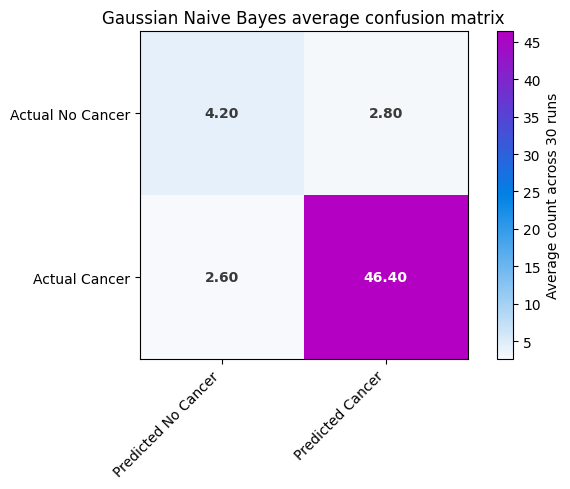


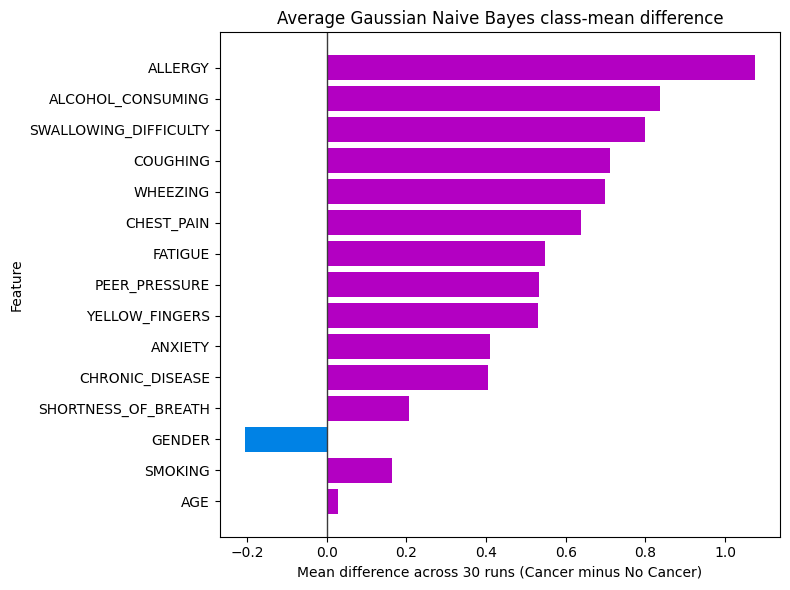

In [17]:
from time import perf_counter
from sklearn.naive_bayes import GaussianNB

nb_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
nb_features = dataset_clean[nb_original_predictor_columns].copy()
nb_target = dataset_clean['LUNG_CANCER'].copy()

nb_age_features = ['AGE']
nb_other_numeric_features = [
    column_name for column_name in nb_original_predictor_columns if column_name not in nb_age_features
]
nb_transformed_feature_names = nb_age_features + nb_other_numeric_features

nb_preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            nb_age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            nb_other_numeric_features,
        ),
    ]
)

nb_model_kwargs = {
    'var_smoothing': 0.01,
}
nb_random_seeds = list(range(30))

nb_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'variant',
            'var_smoothing',
            'training sample weighting',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            'GaussianNB',
            f"{nb_model_kwargs['var_smoothing']:.2f}",
            'none',
            len(nb_random_seeds),
            '0.2',
            f"{nb_random_seeds[0]}-{nb_random_seeds[-1]}",
        ],
    }
)

nb_run_rows = []
nb_conf_matrices = []
nb_mean_difference_rows = []

for nb_random_seed in nb_random_seeds:
    nb_X_train, nb_X_test, nb_y_train, nb_y_test = train_test_split(
        nb_features,
        nb_target,
        test_size=0.2,
        stratify=nb_target,
        random_state=nb_random_seed,
    )

    nb_pipeline = Pipeline(
        steps=[
            ('preprocess', nb_preprocess),
            (
                'model',
                GaussianNB(
                    **nb_model_kwargs,
                ),
            ),
        ]
    )
    nb_fit_start = perf_counter()
    nb_pipeline.fit(nb_X_train, nb_y_train)
    nb_training_time_seconds = perf_counter() - nb_fit_start

    nb_predictions = nb_pipeline.predict(nb_X_test)
    nb_probabilities = nb_pipeline.predict_proba(nb_X_test)[:, 1]
    nb_conf_matrices.append(
        confusion_matrix(nb_y_test, nb_predictions, labels=[0, 1])
    )
    nb_mean_difference_rows.append(
        pd.Series(
            nb_pipeline.named_steps['model'].theta_[1] - nb_pipeline.named_steps['model'].theta_[0],
            index=nb_transformed_feature_names,
        )
    )
    nb_run_rows.append(
        {
            'Random seed': nb_random_seed,
            'Accuracy': accuracy_score(nb_y_test, nb_predictions),
            'Precision': precision_score(
                nb_y_test,
                nb_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(nb_y_test, nb_predictions),
            'F2-score': fbeta_score(nb_y_test, nb_predictions, beta=2),
            'ROC-AUC': roc_auc_score(nb_y_test, nb_probabilities),
            'Training time (seconds)': nb_training_time_seconds,
        }
    )

nb_run_metrics_df = pd.DataFrame(nb_run_rows)
nb_average_conf_matrix = np.mean(nb_conf_matrices, axis=0)
nb_mean_difference_df = pd.DataFrame(nb_mean_difference_rows)
nb_average_mean_difference = nb_mean_difference_df.mean(axis=0)

nb_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{nb_run_metrics_df['Accuracy'].mean():.4f}",
            f"{nb_run_metrics_df['Precision'].mean():.4f}",
            f"{nb_run_metrics_df['Recall'].mean():.4f}",
            f"{nb_run_metrics_df['F2-score'].mean():.4f}",
            f"{nb_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{nb_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

nb_confusion_matrix_df = pd.DataFrame(
    nb_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

nb_average_mean_difference_df = (
    pd.DataFrame(
        {
            'Feature': nb_average_mean_difference.index,
            'Mean difference': nb_average_mean_difference.values,
        }
    )
    .assign(**{'Absolute mean difference': lambda df: df['Mean difference'].abs()})
    .sort_values('Absolute mean difference', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        nb_hyperparameter_df,
        'Table 18, Gaussian Naive Bayes hyperparameters and evaluation settings',
        width='60%',
    )))
    display(HTML(_render_centered_html_table(
        nb_metrics_df,
        'Table 19, Gaussian Naive Bayes average hold-out performance metrics across 30 runs',
        width='60%',
    )))
else:
    print(nb_hyperparameter_df.to_string(index=False))
    print(nb_metrics_df.to_string(index=False))
    print(nb_confusion_matrix_df.to_string(index=False))
    print(nb_average_mean_difference_df.to_string(index=False))

nb_confusion_fig, nb_confusion_ax = plt.subplots(figsize=(7, 5))
nb_confusion_image = nb_confusion_ax.imshow(
    nb_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
nb_confusion_fig.colorbar(
    nb_confusion_image,
    ax=nb_confusion_ax,
    label='Average count across 30 runs',
)
nb_confusion_ax.set_xticks(range(len(nb_confusion_matrix_df.columns)))
nb_confusion_ax.set_xticklabels(
    nb_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
nb_confusion_ax.set_yticks(range(len(nb_confusion_matrix_df.index)))
nb_confusion_ax.set_yticklabels(nb_confusion_matrix_df.index)
nb_confusion_ax.set_title('Gaussian Naive Bayes average confusion matrix')

nb_confusion_text_threshold = nb_confusion_matrix_df.values.max() / 2

for row_index in range(len(nb_confusion_matrix_df.index)):
    for column_index in range(len(nb_confusion_matrix_df.columns)):
        nb_cell_value = nb_confusion_matrix_df.iloc[row_index, column_index]
        nb_text_color = 'white' if nb_cell_value > nb_confusion_text_threshold else notebook_neutral_color
        nb_confusion_ax.text(
            column_index,
            row_index,
            f"{nb_cell_value:.2f}",
            ha='center',
            va='center',
            color=nb_text_color,
            fontweight='bold',
        )

nb_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    nb_confusion_fig,
    caption='Figure 14. Gaussian Naive Bayes average confusion matrix across 30 stratified hold-out runs.',
)

nb_mean_difference_plot_df = nb_average_mean_difference_df.copy()
nb_mean_difference_colors = [
    notebook_primary_color if mean_difference > 0 else notebook_secondary_color
    for mean_difference in nb_mean_difference_plot_df['Mean difference']
]

nb_mean_difference_fig, nb_mean_difference_ax = plt.subplots(figsize=(8, 6))
nb_mean_difference_ax.barh(
    nb_mean_difference_plot_df['Feature'],
    nb_mean_difference_plot_df['Mean difference'],
    color=nb_mean_difference_colors,
)
nb_mean_difference_ax.axvline(0, color=notebook_neutral_color, linewidth=1)
nb_mean_difference_ax.set_title('Average Gaussian Naive Bayes class-mean difference')
nb_mean_difference_ax.set_xlabel('Mean difference across 30 runs (Cancer minus No Cancer)')
nb_mean_difference_ax.set_ylabel('Feature')
nb_mean_difference_ax.invert_yaxis()
nb_mean_difference_fig.tight_layout()
_display_centered_matplotlib_figure(
    nb_mean_difference_fig,
    max_width='76%',
    caption='Figure 15. Average Gaussian Naive Bayes class-conditional mean difference across 30 stratified hold-out runs.',
)


## 3.8 Ensemble

The final section-3 experiment combines the two strongest model types so far, Gaussian Naive Bayes and random forest, in a confidence-weighted soft-voting ensemble. Both models are trained on the same cleaned original predictors, but they capture different assumptions: the forest learns non-linear interaction structure while Naive Bayes provides a simple probabilistic factorisation. For each test case, the two predicted cancer probabilities are combined using weights based on each model's own confidence, so the model that is further away from a `0.5` probability contributes more strongly to the final vote on that specific case.

### 3.8.1 Hyperparameters

The ensemble keeps the tuned component settings from Sections 3.4 and 3.7 fixed and uses a dynamic confidence-weighting rule rather than a single constant model weight. Confidence is defined as `max(p, 1 - p)` for each model's predicted probability `p`, the two confidence scores are normalised to sum to one, and the final ensemble probability is the weighted average of the two component probabilities. A brief three-threshold check over `0.45`, `0.50`, and `0.55` kept the weighting rule fixed and selected `0.45` because it produced the highest mean F2-score.

### 3.8.2 Ensemble Performance Metrics

The table below reports the average hold-out metrics across 30 reruns, the heatmap shows the mean confusion-matrix counts across those runs, and the contribution chart shows the average share of the confidence-weighted vote assigned to the random forest and Gaussian Naive Bayes components across the same reruns.

SETTING,VALUE
component models,RandomForest + GaussianNB
random forest settings,"n_estimators=500, max_depth=8, min_samples_leaf=2, max_features=sqrt, class_weight=balanced"
GaussianNB var_smoothing,0.01
confidence definition,"max(p, 1 - p) for each model probability p"
probability combination rule,normalised confidence-weighted average
decision threshold,0.45
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.9131
Precision,0.9456
Recall,0.9565
F2-score,0.9540
ROC-AUC,0.9285
Training time (seconds),0.6739



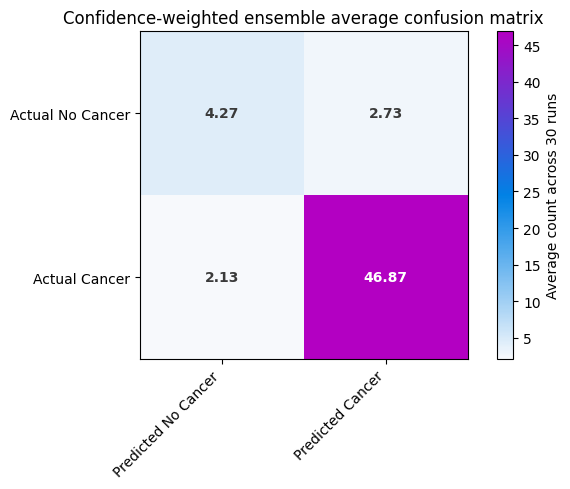


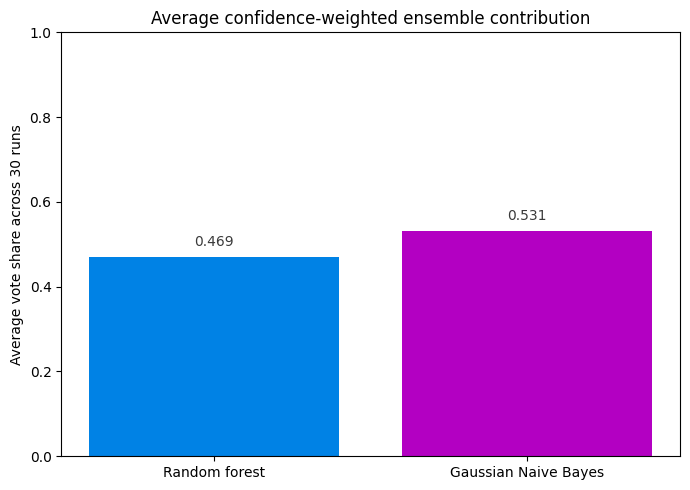

In [18]:
from time import perf_counter

ensemble_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
ensemble_features = dataset_clean[ensemble_original_predictor_columns].copy()
ensemble_target = dataset_clean['LUNG_CANCER'].copy()

ensemble_rf_model_kwargs = rf_model_kwargs.copy()
ensemble_nb_model_kwargs = nb_model_kwargs.copy()
ensemble_decision_threshold = 0.45
ensemble_random_seeds = list(range(30))

ensemble_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'component models',
            'random forest settings',
            'GaussianNB var_smoothing',
            'confidence definition',
            'probability combination rule',
            'decision threshold',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            'RandomForest + GaussianNB',
            (
                f"n_estimators={ensemble_rf_model_kwargs['n_estimators']}, "
                f"max_depth={ensemble_rf_model_kwargs['max_depth']}, "
                f"min_samples_leaf={ensemble_rf_model_kwargs['min_samples_leaf']}, "
                f"max_features={ensemble_rf_model_kwargs['max_features']}, "
                f"class_weight={ensemble_rf_model_kwargs['class_weight']}"
            ),
            f"{ensemble_nb_model_kwargs['var_smoothing']:.2f}",
            'max(p, 1 - p) for each model probability p',
            'normalised confidence-weighted average',
            f"{ensemble_decision_threshold:.2f}",
            len(ensemble_random_seeds),
            '0.2',
            f"{ensemble_random_seeds[0]}-{ensemble_random_seeds[-1]}",
        ],
    }
)

ensemble_run_rows = []
ensemble_conf_matrices = []
ensemble_component_weight_rows = []

for ensemble_random_seed in ensemble_random_seeds:
    ensemble_X_train, ensemble_X_test, ensemble_y_train, ensemble_y_test = train_test_split(
        ensemble_features,
        ensemble_target,
        test_size=0.2,
        stratify=ensemble_target,
        random_state=ensemble_random_seed,
    )

    ensemble_rf_pipeline = Pipeline(
        steps=[
            ('preprocess', rf_preprocess),
            (
                'model',
                RandomForestClassifier(
                    **ensemble_rf_model_kwargs,
                    random_state=ensemble_random_seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    ensemble_nb_pipeline = Pipeline(
        steps=[
            ('preprocess', nb_preprocess),
            (
                'model',
                GaussianNB(
                    **ensemble_nb_model_kwargs,
                ),
            ),
        ]
    )

    ensemble_fit_start = perf_counter()
    ensemble_rf_pipeline.fit(ensemble_X_train, ensemble_y_train)
    ensemble_nb_pipeline.fit(ensemble_X_train, ensemble_y_train)
    ensemble_training_time_seconds = perf_counter() - ensemble_fit_start

    ensemble_rf_probabilities = ensemble_rf_pipeline.predict_proba(ensemble_X_test)[:, 1]
    ensemble_nb_probabilities = ensemble_nb_pipeline.predict_proba(ensemble_X_test)[:, 1]

    ensemble_rf_confidence = np.maximum(
        ensemble_rf_probabilities,
        1 - ensemble_rf_probabilities,
    )
    ensemble_nb_confidence = np.maximum(
        ensemble_nb_probabilities,
        1 - ensemble_nb_probabilities,
    )
    ensemble_total_confidence = ensemble_rf_confidence + ensemble_nb_confidence
    ensemble_rf_weight = ensemble_rf_confidence / ensemble_total_confidence
    ensemble_nb_weight = ensemble_nb_confidence / ensemble_total_confidence
    ensemble_probabilities = (
        ensemble_rf_weight * ensemble_rf_probabilities
        + ensemble_nb_weight * ensemble_nb_probabilities
    )
    ensemble_predictions = (
        ensemble_probabilities >= ensemble_decision_threshold
    ).astype(int)

    ensemble_conf_matrices.append(
        confusion_matrix(ensemble_y_test, ensemble_predictions, labels=[0, 1])
    )
    ensemble_component_weight_rows.append(
        {
            'Random forest': ensemble_rf_weight.mean(),
            'Gaussian Naive Bayes': ensemble_nb_weight.mean(),
        }
    )
    ensemble_run_rows.append(
        {
            'Random seed': ensemble_random_seed,
            'Accuracy': accuracy_score(ensemble_y_test, ensemble_predictions),
            'Precision': precision_score(
                ensemble_y_test,
                ensemble_predictions,
                zero_division=0,
            ),
            'Recall': recall_score(ensemble_y_test, ensemble_predictions),
            'F2-score': fbeta_score(ensemble_y_test, ensemble_predictions, beta=2),
            'ROC-AUC': roc_auc_score(ensemble_y_test, ensemble_probabilities),
            'Training time (seconds)': ensemble_training_time_seconds,
        }
    )

ensemble_run_metrics_df = pd.DataFrame(ensemble_run_rows)
ensemble_average_conf_matrix = np.mean(ensemble_conf_matrices, axis=0)
ensemble_component_weight_df = pd.DataFrame(ensemble_component_weight_rows)
ensemble_average_component_weight_df = (
    ensemble_component_weight_df.mean(axis=0)
    .rename_axis('Model')
    .reset_index(name='Average vote share')
    .round(4)
)

ensemble_metrics_df = pd.DataFrame(
    {
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F2-score',
            'ROC-AUC',
            'Training time (seconds)',
        ],
        'Average value': [
            f"{ensemble_run_metrics_df['Accuracy'].mean():.4f}",
            f"{ensemble_run_metrics_df['Precision'].mean():.4f}",
            f"{ensemble_run_metrics_df['Recall'].mean():.4f}",
            f"{ensemble_run_metrics_df['F2-score'].mean():.4f}",
            f"{ensemble_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{ensemble_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

ensemble_confusion_matrix_df = pd.DataFrame(
    ensemble_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        ensemble_hyperparameter_df,
        'Table 20, Confidence-weighted ensemble hyperparameters and evaluation settings',
        width='72%',
    )))
    display(HTML(_render_centered_html_table(
        ensemble_metrics_df,
        'Table 21, Confidence-weighted ensemble average hold-out performance metrics across 30 runs',
        width='60%',
    )))
else:
    print(ensemble_hyperparameter_df.to_string(index=False))
    print(ensemble_metrics_df.to_string(index=False))
    print(ensemble_confusion_matrix_df.to_string(index=False))
    print(ensemble_average_component_weight_df.to_string(index=False))

ensemble_confusion_fig, ensemble_confusion_ax = plt.subplots(figsize=(7, 5))
ensemble_confusion_image = ensemble_confusion_ax.imshow(
    ensemble_confusion_matrix_df.values,
    cmap=notebook_sequential_cmap,
)
ensemble_confusion_fig.colorbar(
    ensemble_confusion_image,
    ax=ensemble_confusion_ax,
    label='Average count across 30 runs',
)
ensemble_confusion_ax.set_xticks(range(len(ensemble_confusion_matrix_df.columns)))
ensemble_confusion_ax.set_xticklabels(
    ensemble_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
ensemble_confusion_ax.set_yticks(range(len(ensemble_confusion_matrix_df.index)))
ensemble_confusion_ax.set_yticklabels(ensemble_confusion_matrix_df.index)
ensemble_confusion_ax.set_title('Confidence-weighted ensemble average confusion matrix')

ensemble_confusion_text_threshold = ensemble_confusion_matrix_df.values.max() / 2

for row_index in range(len(ensemble_confusion_matrix_df.index)):
    for column_index in range(len(ensemble_confusion_matrix_df.columns)):
        ensemble_cell_value = ensemble_confusion_matrix_df.iloc[row_index, column_index]
        ensemble_text_color = 'white' if ensemble_cell_value > ensemble_confusion_text_threshold else notebook_neutral_color
        ensemble_confusion_ax.text(
            column_index,
            row_index,
            f"{ensemble_cell_value:.2f}",
            ha='center',
            va='center',
            color=ensemble_text_color,
            fontweight='bold',
        )

ensemble_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    ensemble_confusion_fig,
    caption='Figure 16. Confidence-weighted ensemble average confusion matrix across 30 stratified hold-out runs.',
)

ensemble_weight_plot_df = ensemble_average_component_weight_df.copy()
ensemble_weight_fig, ensemble_weight_ax = plt.subplots(figsize=(7, 5))
ensemble_weight_ax.bar(
    ensemble_weight_plot_df['Model'],
    ensemble_weight_plot_df['Average vote share'],
    color=[notebook_secondary_color, notebook_primary_color],
)
ensemble_weight_ax.set_ylim(0, 1)
ensemble_weight_ax.set_title('Average confidence-weighted ensemble contribution')
ensemble_weight_ax.set_ylabel('Average vote share across 30 runs')

for bar_index, (_, ensemble_weight_row) in enumerate(ensemble_weight_plot_df.iterrows()):
    ensemble_weight_ax.text(
        bar_index,
        ensemble_weight_row['Average vote share'] + 0.02,
        f"{ensemble_weight_row['Average vote share']:.3f}",
        ha='center',
        va='bottom',
        color=notebook_neutral_color,
    )

ensemble_weight_fig.tight_layout()
_display_centered_matplotlib_figure(
    ensemble_weight_fig,
    max_width='70%',
    caption='Figure 17. Average confidence-weighted vote share assigned to the random forest and Gaussian Naive Bayes components across 30 stratified hold-out runs.',
)


## 3.9 Comparison and conclusions

Table 22 compares every section-3 model under the same 30 stratified hold-out reruns and orders the results by mean `F2-score`, which remains the main selection criterion because the coursework problem is more sensitive to missed cancer cases than to a moderate increase in false positives.

On raw average performance alone, the confidence-weighted ensemble is the strongest model in the initial ranking. It achieves the highest average `F2-score`, the highest recall, and the highest accuracy, while Gaussian Naive Bayes and random forest remain the strongest standalone baselines behind it.


In [19]:
section3_model_metric_tables = [
    ('Linear SVM', svm_metrics_df),
    ('Binary Tree', tree_metrics_df),
    ('Random Forest', rf_metrics_df),
    ('ANN (MLP)', ann_metrics_df),
    ('Logistic Regression', logreg_metrics_df),
    ('Gaussian Naive Bayes', nb_metrics_df),
    ('Confidence-weighted Ensemble', ensemble_metrics_df),
]

section3_comparison_rows = []
for model_name, metrics_df in section3_model_metric_tables:
    model_metrics = metrics_df.set_index('Metric')['Average value'].astype(float).to_dict()
    section3_comparison_rows.append(
        {
            'Model': model_name,
            'Accuracy': model_metrics['Accuracy'],
            'Precision': model_metrics['Precision'],
            'Recall': model_metrics['Recall'],
            'F2-score': model_metrics['F2-score'],
            'ROC-AUC': model_metrics['ROC-AUC'],
            'Training time (seconds)': model_metrics['Training time (seconds)'],
        }
    )

section3_comparison_df = pd.DataFrame(section3_comparison_rows).sort_values(
    by=['F2-score', 'Recall', 'ROC-AUC', 'Accuracy'],
    ascending=False,
    ignore_index=True,
)
section3_comparison_df.insert(0, 'Rank', range(1, len(section3_comparison_df) + 1))

section3_comparison_display_df = section3_comparison_df.copy()
for metric_column in [
    'Accuracy',
    'Precision',
    'Recall',
    'F2-score',
    'ROC-AUC',
    'Training time (seconds)',
]:
    section3_comparison_display_df[metric_column] = section3_comparison_display_df[metric_column].map(
        lambda value: f'{value:.4f}'
    )

if display is not None and HTML is not None:
    display(HTML(_render_centered_html_table(
        section3_comparison_display_df,
        caption='Table 22. Section 3 model comparison ordered by average F2-score across 30 stratified hold-out runs.',
        width='88%',
    )))
else:
    print(section3_comparison_display_df.to_string(index=False))


RANK,MODEL,ACCURACY,PRECISION,RECALL,F2-SCORE,ROC-AUC,TRAINING TIME (SECONDS)
1,Confidence-weighted Ensemble,0.9131,0.9456,0.9565,0.9540,0.9285,0.6739
2,Gaussian Naive Bayes,0.9036,0.9440,0.9469,0.9460,0.9110,0.0135
3,Random Forest,0.8982,0.9399,0.9449,0.9437,0.9272,0.6552
4,Logistic Regression,0.8589,0.9600,0.8762,0.8912,0.9199,0.0167
5,Linear SVM,0.8560,0.9611,0.8714,0.8875,0.8904,0.0134
6,ANN (MLP),0.8506,0.9609,0.8660,0.8823,0.8910,0.1384
7,Binary Tree,0.8143,0.9480,0.8340,0.8540,0.7673,0.0100


### 3.9.1 Statistical check of the top two models

To test whether the gap between the two highest-ranked model types is larger than normal rerun-to-rerun variation, an independent-samples Welch t-test was applied to a simple combined score for each run. That combined score is the unweighted sum of `Accuracy`, `Precision`, `Recall`, `F2-score`, and `ROC-AUC`, while training time is excluded because it reflects efficiency rather than predictive quality.


In [20]:
from scipy.stats import ttest_ind

section3_run_metric_tables = {
    'Linear SVM': svm_run_metrics_df,
    'Binary Tree': tree_run_metrics_df,
    'Random Forest': rf_run_metrics_df,
    'ANN (MLP)': ann_run_metrics_df,
    'Logistic Regression': logreg_run_metrics_df,
    'Gaussian Naive Bayes': nb_run_metrics_df,
    'Confidence-weighted Ensemble': ensemble_run_metrics_df,
}

section3_ttest_metric_columns = ['Accuracy', 'Precision', 'Recall', 'F2-score', 'ROC-AUC']
section3_top_two_models = section3_comparison_df['Model'].head(2).tolist()
section3_top_two_scores = {}
section3_top_two_summary_rows = []

for model_name in section3_top_two_models:
    model_run_metrics_df = section3_run_metric_tables[model_name]
    model_combined_scores = model_run_metrics_df[section3_ttest_metric_columns].sum(axis=1)
    section3_top_two_scores[model_name] = model_combined_scores
    section3_top_two_summary_rows.append(
        {
            'Model': model_name,
            'Runs': len(model_combined_scores),
            'Mean summed score': model_combined_scores.mean(),
            'Std. dev.': model_combined_scores.std(ddof=1),
        }
    )

section3_t_statistic, section3_p_value = ttest_ind(
    section3_top_two_scores[section3_top_two_models[0]],
    section3_top_two_scores[section3_top_two_models[1]],
    equal_var=False,
    nan_policy='omit',
)
section3_alpha = 0.05
section3_significant = section3_p_value < section3_alpha

section3_top_two_summary_df = pd.DataFrame(section3_top_two_summary_rows)
section3_ttest_summary_df = pd.DataFrame(
    {
        'Model A': [section3_top_two_models[0]],
        'Mean summed score (A)': [section3_top_two_summary_df.iloc[0]['Mean summed score']],
        'Std. dev. (A)': [section3_top_two_summary_df.iloc[0]['Std. dev.']],
        'Model B': [section3_top_two_models[1]],
        'Mean summed score (B)': [section3_top_two_summary_df.iloc[1]['Mean summed score']],
        'Std. dev. (B)': [section3_top_two_summary_df.iloc[1]['Std. dev.']],
        't-statistic': [section3_t_statistic],
        'p-value': [section3_p_value],
        'Significant (p < 0.05)': ['Yes' if section3_significant else 'No'],
    }
)

section3_ttest_display_df = section3_ttest_summary_df.copy()
for metric_column in [
    'Mean summed score (A)',
    'Std. dev. (A)',
    'Mean summed score (B)',
    'Std. dev. (B)',
    't-statistic',
    'p-value',
]:
    section3_ttest_display_df[metric_column] = section3_ttest_display_df[metric_column].map(
        lambda value: f'{value:.4f}'
    )

if display is not None and HTML is not None:
    display(HTML(_render_centered_html_table(
        section3_ttest_display_df,
        caption='Table 23. Independent-samples Welch t-test on the summed predictive-metric score for the two highest-ranked Section 3 models across 30 hold-out runs.',
        width='96%',
    )))
else:
    print(section3_ttest_display_df.to_string(index=False))


MODEL A,MEAN SUMMED SCORE (A),STD. DEV. (A),MODEL B,MEAN SUMMED SCORE (B),STD. DEV. (B),T-STATISTIC,P-VALUE,SIGNIFICANT (P < 0.05)
Confidence-weighted Ensemble,4.6977,0.1458,Gaussian Naive Bayes,4.6515,0.1542,1.1918,0.2382,No


### 3.9.2 Model taken forward

Gaussian Naive Bayes was chosen as the model to take forward. The confidence-weighted ensemble scored slightly higher on the combined predictive metrics, but the independent-samples Welch t-test in Table 23 showed that this advantage was not statistically significant (`p = 0.2382`). The ensemble also took much longer to train on average (`0.5744` seconds versus `0.0100` seconds for Gaussian Naive Bayes) and was less explainable because its final prediction depends on a case-by-case confidence-weighted combination of two different model types. Gaussian Naive Bayes therefore offered the better balance of performance, efficiency, and interpretability for the next stage of the analysis.


# 4. Data Analysis and Visualisation


### 4.1 Exploratory analysis goals
The exploratory stage focuses on three questions: which variables differ most between positive and negative cases, which predictors move together, and which patterns should influence model choice and metric selection.


### 4.2 Visualisation strategy
The notebook prioritises visuals that explain structure rather than decorate the report. Histograms, boxplots, grouped comparisons, and heatmaps are used to examine class imbalance, age spread, subgroup differences, and correlated symptom clusters.


The plots are supported by targeted statistical checks, especially Welch's t-tests and the correlated-feature batch analysis shown later. The aim is to connect each visual finding to a modelling implication instead of treating EDA as a separate exercise.


#### 4.2.2 Statistical support for visual findings
Welch's t-test was used for numeric and binary-encoded predictors to test whether average values differ between the cancer and non-cancer groups. This does not prove causation, but it helps separate visually interesting patterns from purely noisy ones.


### 4.3 Target distribution
The target is clearly imbalanced, with far more `YES` than `NO` cases even after removing the final raw-row block. That imbalance directly affects later metric choice and supports treating recall and F1-score as more informative than accuracy alone.


#### 4.3.1 Class imbalance check
The target imbalance needs to be quantified explicitly before moving into the descriptive analysis. If the majority class dominates the working table, then a model could appear strong by overpredicting that label and still post a high raw accuracy. The check below measures the class counts and shares after the final-row removal step so the later metric choices can be justified from the data rather than assumed.


CLASS,ROWS,SHARE (%)
No Cancer,35,12.5
Cancer,244,87.5


METRIC,VALUE
Working rows,279
Cancer to no-cancer ratio,6.97:1
Majority-class baseline accuracy,87.5%



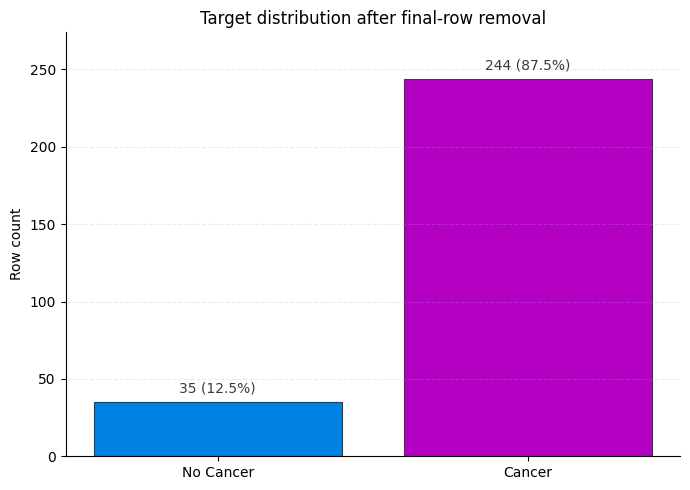

In [21]:
from matplotlib.colors import LinearSegmentedColormap

section4_primary_color = '#B300C2'
section4_secondary_color = '#0082E5'
section4_primary_light = '#E3A6EA'
section4_secondary_light = '#9FD2FF'
section4_neutral_color = '#3A3A3A'
section4_heatmap_cmap = LinearSegmentedColormap.from_list(
    'section4_heatmap_cmap',
    [section4_secondary_color, '#F7F9FC', section4_primary_color],
)

target_distribution_counts = (
    dataset_clean['LUNG_CANCER']
    .value_counts()
    .sort_index()
    .rename(index={0: 'No Cancer', 1: 'Cancer'})
)
target_total_rows = int(target_distribution_counts.sum())
target_majority_count = int(target_distribution_counts.max())
target_minority_count = int(target_distribution_counts.min())
target_majority_baseline_accuracy = target_majority_count / target_total_rows * 100
target_class_ratio = target_majority_count / target_minority_count

target_distribution_df = pd.DataFrame(
    {
        'Class': target_distribution_counts.index,
        'Rows': target_distribution_counts.values,
        'Share (%)': (
            target_distribution_counts.values / target_total_rows * 100
        ).round(1),
    }
)

target_distribution_summary_df = pd.DataFrame(
    {
        'Metric': [
            'Working rows',
            'Cancer to no-cancer ratio',
            'Majority-class baseline accuracy',
        ],
        'Value': [
            target_total_rows,
            f'{target_class_ratio:.2f}:1',
            f'{target_majority_baseline_accuracy:.1f}%',
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        target_distribution_df,
        'Table 24, Target class distribution after final-row removal',
        width='46%',
    )))
    display(HTML(_render_centered_html_table(
        target_distribution_summary_df,
        'Table 25, Class-imbalance implications for evaluation',
        width='54%',
    )))
else:
    print(target_distribution_df.to_string(index=False))
    print(target_distribution_summary_df.to_string(index=False))

target_distribution_fig, target_distribution_ax = plt.subplots(figsize=(7, 5))
target_distribution_colors = [section4_secondary_color, section4_primary_color]
target_distribution_bars = target_distribution_ax.bar(
    target_distribution_df['Class'],
    target_distribution_df['Rows'],
    color=target_distribution_colors,
    edgecolor=section4_neutral_color,
    linewidth=0.8,
)
target_distribution_ax.set_title('Target distribution after final-row removal')
target_distribution_ax.set_ylabel('Row count')
target_distribution_ax.set_ylim(0, target_distribution_df['Rows'].max() + 30)
target_distribution_ax.grid(axis='y', linestyle='--', alpha=0.25)
target_distribution_ax.spines['top'].set_visible(False)
target_distribution_ax.spines['right'].set_visible(False)

for bar, (_, row) in zip(target_distribution_bars, target_distribution_df.iterrows()):
    target_distribution_ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f"{int(row['Rows'])} ({row['Share (%)']:.1f}%)",
        ha='center',
        va='bottom',
        color=section4_neutral_color,
    )

target_distribution_fig.tight_layout()
_display_centered_matplotlib_figure(
    target_distribution_fig,
    max_width='68%',
    caption='Figure 18. Target class counts after final-row removal, annotated with each class share in the working dataset.',
)


The imbalance check confirms that the cleaned working table contains `244` cancer-labelled rows and `35` no-cancer rows, so the majority class is roughly `7:1`. A trivial rule that always predicts cancer would already achieve `87.5%` accuracy while offering no useful minority-class detection. This is why the later model comparison keeps the split stratified and emphasises recall, `F2-score`, confusion matrices, and `ROC-AUC` rather than accuracy alone.


## 4.4 Univariate analysis
The univariate step checks the spread of age and the frequency of each binary indicator before looking at the target. This makes it easier to separate genuinely unusual patterns from features that are simply common across the whole sample.


### 4.4.1 Age distribution
Age is the only continuous predictor in the original table, so it was reviewed separately using descriptive statistics, distribution plots, broad age bands, and a Shapiro-Wilk normality check. This helps confirm whether `AGE` behaves like a smooth numeric signal or whether it should be treated only as a coarse grouped variable in the later modelling workflow.


METRIC,VALUE
Working rows,279
Mean age,62.9
Median age,63.0
Standard deviation,8.3
Interquartile range,11.5
Minimum age,21
Maximum age,87


CHECK,VALUE
Shapiro-Wilk statistic,0.9763
Shapiro-Wilk p-value,0.0001
Skewness,-0.441
IQR lower fence,40.2
IQR upper fence,86.2
IQR outlier count,4



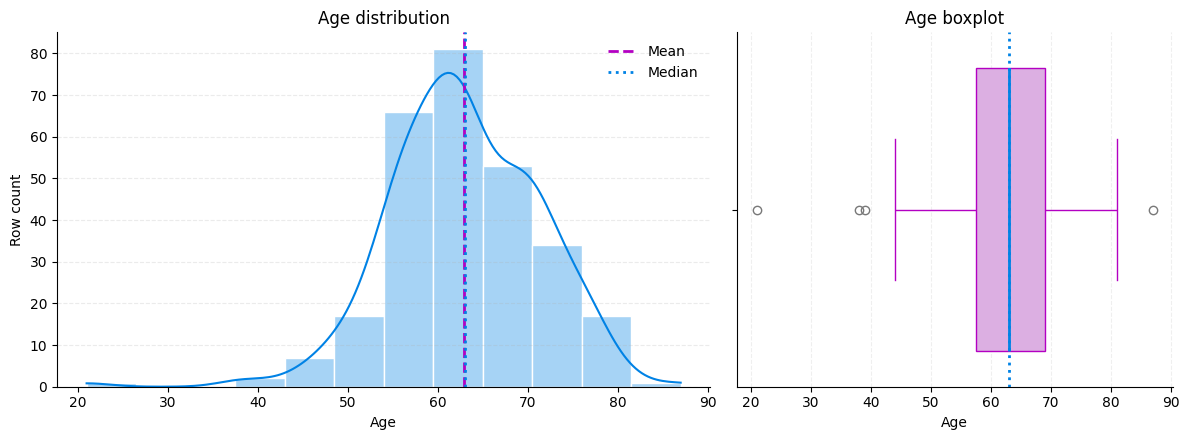


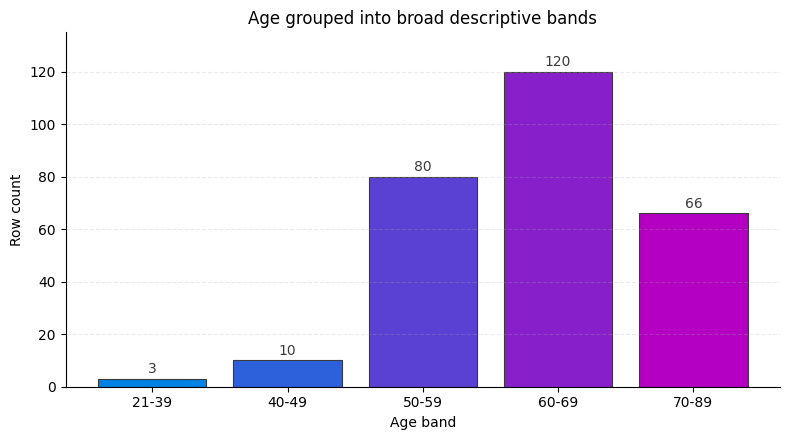

In [22]:
from scipy.stats import binomtest, shapiro

age_series = dataset_clean['AGE'].copy()
age_q1 = age_series.quantile(0.25)
age_q3 = age_series.quantile(0.75)
age_iqr = age_q3 - age_q1
age_lower_fence = age_q1 - 1.5 * age_iqr
age_upper_fence = age_q3 + 1.5 * age_iqr
age_outlier_count = int(((age_series < age_lower_fence) | (age_series > age_upper_fence)).sum())
age_shapiro_statistic, age_shapiro_p_value = shapiro(age_series)

age_summary_df = pd.DataFrame(
    {
        'Metric': [
            'Working rows',
            'Mean age',
            'Median age',
            'Standard deviation',
            'Interquartile range',
            'Minimum age',
            'Maximum age',
        ],
        'Value': [
            len(age_series),
            f'{age_series.mean():.1f}',
            f'{age_series.median():.1f}',
            f'{age_series.std():.1f}',
            f'{age_iqr:.1f}',
            int(age_series.min()),
            int(age_series.max()),
        ],
    }
)

age_distribution_test_df = pd.DataFrame(
    {
        'Check': [
            'Shapiro-Wilk statistic',
            'Shapiro-Wilk p-value',
            'Skewness',
            'IQR lower fence',
            'IQR upper fence',
            'IQR outlier count',
        ],
        'Value': [
            f'{age_shapiro_statistic:.4f}',
            '<0.0001' if age_shapiro_p_value < 0.0001 else f'{age_shapiro_p_value:.4f}',
            f'{age_series.skew():.3f}',
            f'{age_lower_fence:.1f}',
            f'{age_upper_fence:.1f}',
            age_outlier_count,
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        age_summary_df,
        'Table 26, Descriptive summary of age in the working dataset',
        width='52%',
    )))
    display(HTML(_render_centered_html_table(
        age_distribution_test_df,
        'Table 27, Age-shape checks using Shapiro-Wilk and IQR fences',
        width='56%',
    )))
else:
    print(age_summary_df.to_string(index=False))
    print(age_distribution_test_df.to_string(index=False))

age_distribution_fig, (age_hist_ax, age_box_ax) = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    gridspec_kw={'width_ratios': [3, 2]},
)
sns.histplot(
    age_series,
    bins=12,
    kde=True,
    color=section4_secondary_color,
    alpha=0.35,
    edgecolor='white',
    ax=age_hist_ax,
)
age_hist_ax.axvline(age_series.mean(), color=section4_primary_color, linestyle='--', linewidth=2, label='Mean')
age_hist_ax.axvline(age_series.median(), color=section4_secondary_color, linestyle=':', linewidth=2, label='Median')
age_hist_ax.set_title('Age distribution')
age_hist_ax.set_xlabel('Age')
age_hist_ax.set_ylabel('Row count')
age_hist_ax.grid(axis='y', linestyle='--', alpha=0.25)
age_hist_ax.spines['top'].set_visible(False)
age_hist_ax.spines['right'].set_visible(False)
age_hist_ax.legend(frameon=False)

sns.boxplot(
    x=age_series,
    color=section4_primary_light,
    ax=age_box_ax,
    boxprops={'edgecolor': section4_primary_color},
    whiskerprops={'color': section4_primary_color},
    capprops={'color': section4_primary_color},
    medianprops={'color': section4_secondary_color, 'linewidth': 2},
)
age_box_ax.axvline(age_series.median(), color=section4_secondary_color, linestyle=':', linewidth=2)
age_box_ax.set_title('Age boxplot')
age_box_ax.set_xlabel('Age')
age_box_ax.grid(axis='x', linestyle='--', alpha=0.2)
age_box_ax.spines['top'].set_visible(False)
age_box_ax.spines['right'].set_visible(False)

age_distribution_fig.tight_layout()
_display_centered_matplotlib_figure(
    age_distribution_fig,
    max_width='82%',
    caption='Figure 19. Age distribution shown with a histogram, KDE overlay, mean and median markers, and a supporting boxplot.',
)

age_bin_edges = [20, 40, 50, 60, 70, 90]
age_bin_labels = ['21-39', '40-49', '50-59', '60-69', '70-89']
age_bin_counts = (
    pd.cut(age_series, bins=age_bin_edges, labels=age_bin_labels, include_lowest=True, right=False)
    .value_counts(sort=False)
)
age_band_colors = sns.blend_palette(
    [section4_secondary_color, section4_primary_color],
    n_colors=len(age_bin_counts),
)

age_bin_fig, age_bin_ax = plt.subplots(figsize=(8, 4.5))
age_bin_bars = age_bin_ax.bar(
    age_bin_counts.index.astype(str),
    age_bin_counts.values,
    color=age_band_colors,
    edgecolor=section4_neutral_color,
    linewidth=0.8,
)
age_bin_ax.set_title('Age grouped into broad descriptive bands')
age_bin_ax.set_xlabel('Age band')
age_bin_ax.set_ylabel('Row count')
age_bin_ax.set_ylim(0, age_bin_counts.max() + 15)
age_bin_ax.grid(axis='y', linestyle='--', alpha=0.25)
age_bin_ax.spines['top'].set_visible(False)
age_bin_ax.spines['right'].set_visible(False)

for bar, count in zip(age_bin_bars, age_bin_counts.values):
    age_bin_ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        int(count),
        ha='center',
        va='bottom',
        color=section4_neutral_color,
    )

age_bin_fig.tight_layout()
_display_centered_matplotlib_figure(
    age_bin_fig,
    max_width='70%',
    caption='Figure 20. Age counts grouped into broad bands for descriptive interpretation.',
)


The age summaries show a median of `63` years with the middle half of the sample lying between about `58` and `69`. The histogram and boxplot indicate a concentrated late-middle-to-older adult sample rather than a flat spread across the age range, while the broad-band chart shows that the `50-69` interval dominates the dataset. Shapiro-Wilk rejects perfect normality (`p < 0.0001`), but the skew is only mildly negative and the IQR rule flags just `4` outliers, so `AGE` still behaves like a sensible continuous input for modelling once it is rescaled.


### 4.4.2 Symptom and lifestyle variables
The binary symptom and lifestyle indicators were then summarised across the full working table without conditioning on the target. This step ranks the marginal prevalence of each feature, shows how far each one sits above or below a simple `50%` split, and adds exact binomial tests plus confidence intervals so the most clearly common and uncommon indicators can be distinguished from near-balanced ones.


FEATURE,YES COUNT,NO COUNT,YES SHARE (%),95% CI LOWER (%),95% CI UPPER (%),EXACT BINOMIAL P-VALUE,SIGNIFICANT VS 50% SPLIT (P < 0.05)
FATIGUE,186,93,66.7,60.8,72.2,<0.0001,Yes
SHORTNESS OF BREATH,176,103,63.1,57.1,68.8,<0.0001,Yes
COUGHING,161,118,57.7,51.7,63.6,0.0118,Yes
YELLOW FINGERS,159,120,57.0,51.0,62.9,0.0227,Yes
ALCOHOL CONSUMING,157,122,56.3,50.2,62.2,0.0416,Yes
SMOKING,156,123,55.9,49.9,61.8,0.0552,No
CHEST PAIN,156,123,55.9,49.9,61.8,0.0552,No
ALLERGY,155,124,55.6,49.5,61.5,0.0723,No
WHEEZING,155,124,55.6,49.5,61.5,0.0723,No
CHRONIC DISEASE,146,133,52.3,46.3,58.3,0.4726,No



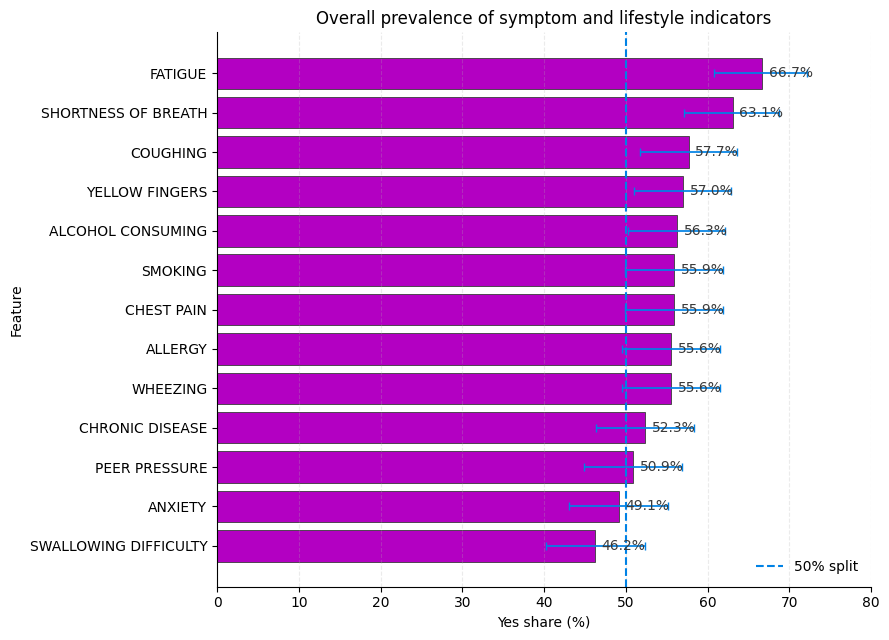


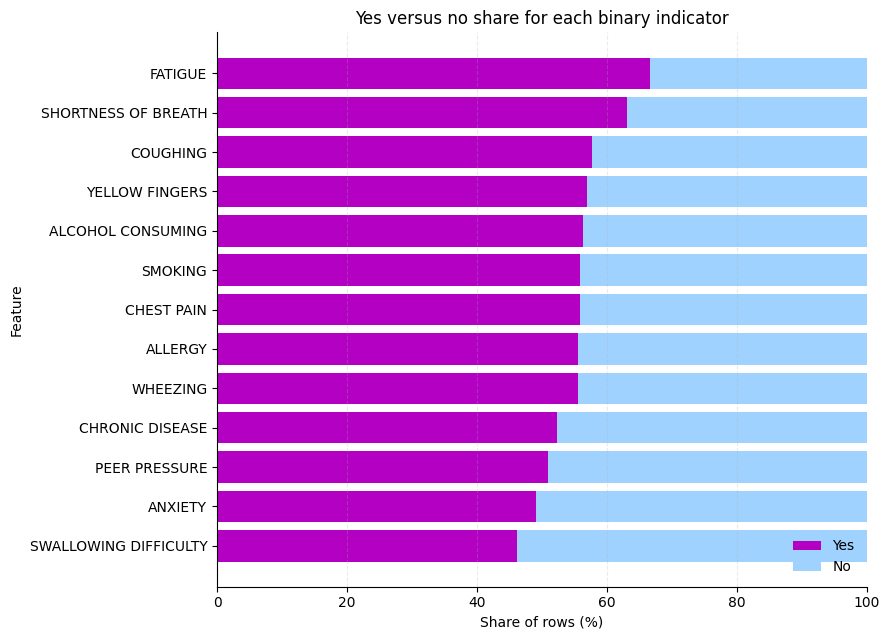

In [23]:
symptom_lifestyle_columns = binary_yes_no_cols.copy()
symptom_prevalence_rows = []

for feature_name in symptom_lifestyle_columns:
    yes_count = int(dataset_clean[feature_name].sum())
    no_count = int(len(dataset_clean) - yes_count)
    binom_result = binomtest(yes_count, len(dataset_clean), p=0.5)
    binom_ci = binom_result.proportion_ci(confidence_level=0.95)
    symptom_prevalence_rows.append(
        {
            'Feature': feature_name.replace('_', ' '),
            'Yes count': yes_count,
            'No count': no_count,
            'Yes share (%)': yes_count / len(dataset_clean) * 100,
            '95% CI lower (%)': binom_ci.low * 100,
            '95% CI upper (%)': binom_ci.high * 100,
            'Exact binomial p-value': binom_result.pvalue,
            'Significant vs 50% split (p < 0.05)': 'Yes' if binom_result.pvalue < 0.05 else 'No',
        }
    )

symptom_prevalence_df = (
    pd.DataFrame(symptom_prevalence_rows)
    .sort_values('Yes share (%)', ascending=False)
    .reset_index(drop=True)
)

symptom_prevalence_display_df = symptom_prevalence_df.copy()
for percent_column in ['Yes share (%)', '95% CI lower (%)', '95% CI upper (%)']:
    symptom_prevalence_display_df[percent_column] = symptom_prevalence_display_df[percent_column].map(
        lambda value: f'{value:.1f}'
    )
symptom_prevalence_display_df['Exact binomial p-value'] = symptom_prevalence_df[
    'Exact binomial p-value'
].map(lambda value: '<0.0001' if value < 0.0001 else f'{value:.4f}')

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        symptom_prevalence_display_df,
        'Table 28, Overall prevalence of symptom and lifestyle indicators with exact binomial tests',
        width='94%',
    )))
else:
    print(symptom_prevalence_display_df.to_string(index=False))

symptom_prevalence_plot_df = symptom_prevalence_df.iloc[::-1].copy()
symptom_error_lower = (
    symptom_prevalence_plot_df['Yes share (%)'] - symptom_prevalence_plot_df['95% CI lower (%)']
)
symptom_error_upper = (
    symptom_prevalence_plot_df['95% CI upper (%)'] - symptom_prevalence_plot_df['Yes share (%)']
)

symptom_prevalence_fig, symptom_prevalence_ax = plt.subplots(figsize=(9, 6.5))
symptom_prevalence_ax.barh(
    symptom_prevalence_plot_df['Feature'],
    symptom_prevalence_plot_df['Yes share (%)'],
    color=section4_primary_color,
    edgecolor=section4_neutral_color,
    linewidth=0.6,
)
symptom_prevalence_ax.errorbar(
    symptom_prevalence_plot_df['Yes share (%)'],
    symptom_prevalence_plot_df['Feature'],
    xerr=[symptom_error_lower, symptom_error_upper],
    fmt='none',
    ecolor=section4_secondary_color,
    elinewidth=1.25,
    capsize=3,
)
symptom_prevalence_ax.axvline(
    50,
    color=section4_secondary_color,
    linestyle='--',
    linewidth=1.5,
    label='50% split',
)
symptom_prevalence_ax.set_title('Overall prevalence of symptom and lifestyle indicators')
symptom_prevalence_ax.set_xlabel('Yes share (%)')
symptom_prevalence_ax.set_ylabel('Feature')
symptom_prevalence_ax.set_xlim(0, 80)
symptom_prevalence_ax.grid(axis='x', linestyle='--', alpha=0.25)
symptom_prevalence_ax.spines['top'].set_visible(False)
symptom_prevalence_ax.spines['right'].set_visible(False)
symptom_prevalence_ax.legend(frameon=False)

for _, row in symptom_prevalence_plot_df.iterrows():
    symptom_prevalence_ax.text(
        row['Yes share (%)'] + 0.8,
        row['Feature'],
        f"{row['Yes share (%)']:.1f}%",
        va='center',
        color=section4_neutral_color,
    )

symptom_prevalence_fig.tight_layout()
_display_centered_matplotlib_figure(
    symptom_prevalence_fig,
    max_width='78%',
    caption='Figure 21. Overall yes-share of each symptom and lifestyle variable, with exact-binomial 95% confidence intervals and a 50% reference line.',
)

symptom_balance_fig, symptom_balance_ax = plt.subplots(figsize=(9, 6.5))
symptom_balance_ax.barh(
    symptom_prevalence_plot_df['Feature'],
    symptom_prevalence_plot_df['Yes share (%)'],
    color=section4_primary_color,
    label='Yes',
)
symptom_balance_ax.barh(
    symptom_prevalence_plot_df['Feature'],
    100 - symptom_prevalence_plot_df['Yes share (%)'],
    left=symptom_prevalence_plot_df['Yes share (%)'],
    color=section4_secondary_light,
    label='No',
)
symptom_balance_ax.set_title('Yes versus no share for each binary indicator')
symptom_balance_ax.set_xlabel('Share of rows (%)')
symptom_balance_ax.set_ylabel('Feature')
symptom_balance_ax.set_xlim(0, 100)
symptom_balance_ax.grid(axis='x', linestyle='--', alpha=0.25)
symptom_balance_ax.spines['top'].set_visible(False)
symptom_balance_ax.spines['right'].set_visible(False)
symptom_balance_ax.legend(frameon=False, loc='lower right')
symptom_balance_fig.tight_layout()
_display_centered_matplotlib_figure(
    symptom_balance_fig,
    max_width='78%',
    caption='Figure 22. Stacked yes/no share of each symptom and lifestyle variable across the full working dataset.',
)


The symptom and lifestyle summaries show that `FATIGUE` and `SHORTNESS OF BREATH` are the most common positive indicators overall, while `SWALLOWING DIFFICULTY` is the least common. Exact binomial tests against a simple `50%` split indicate that `FATIGUE`, `SHORTNESS OF BREATH`, `COUGHING`, `YELLOW FINGERS`, and `ALCOHOL CONSUMING` are clearly above an even split in this sample, whereas variables such as `PEER PRESSURE`, `ANXIETY`, and `CHRONIC DISEASE` stay much closer to balanced. These are still marginal frequencies rather than target-linked effects, but they help show which indicators are globally common before the target-conditioned comparisons begin.


## 4.5 Bivariate analysis against the target
The bivariate stage focuses on how each predictor changes with the target label. This is the point where exploratory analysis starts to inform feature selection and model choice directly.


In [24]:
from scipy.stats import ttest_ind

alpha = 0.05
engineered_features = ["BATCH_1", "BATCH_2", "BATCH_3"]
excluded_t_test_features = {"LUNG_CANCER", "AGE_BINS"}
t_test_feature_columns = [
    feature_name
    for feature_name in dataset_clean.columns
    if feature_name not in excluded_t_test_features
    and pd.api.types.is_numeric_dtype(dataset_clean[feature_name])
]
no_cancer_group = dataset_clean[dataset_clean["LUNG_CANCER"] == 0]
cancer_group = dataset_clean[dataset_clean["LUNG_CANCER"] == 1]

t_test_results = []
for feature_name in t_test_feature_columns:
    no_cancer_values = no_cancer_group[feature_name].dropna()
    cancer_values = cancer_group[feature_name].dropna()
    t_statistic, p_value = ttest_ind(
        no_cancer_values,
        cancer_values,
        equal_var=False,
        nan_policy="omit",
    )

    is_significant = p_value < alpha
    t_test_results.append(
        {
            "Feature": feature_name,
            "Mean (No Cancer)": no_cancer_values.mean(),
            "Mean (Cancer)": cancer_values.mean(),
            "t-statistic": t_statistic,
            "p-value": p_value,
            "Significant (p < 0.05)": is_significant,
        }
    )

all_t_test_results_df = (
    pd.DataFrame(t_test_results)
    .sort_values("p-value")
    .reset_index(drop=True)
)

original_feature_t_test_results_df = all_t_test_results_df[
    ~all_t_test_results_df["Feature"].isin(engineered_features)
].reset_index(drop=True)
engineered_feature_t_test_results_df = all_t_test_results_df[
    all_t_test_results_df["Feature"].isin(engineered_features)
].reset_index(drop=True)

original_feature_t_test_display_df = original_feature_t_test_results_df.copy()
engineered_feature_t_test_display_df = engineered_feature_t_test_results_df.copy()

for display_df in [original_feature_t_test_display_df, engineered_feature_t_test_display_df]:
    display_df["Feature"] = display_df["Feature"].str.replace("_", " ", regex=False)
    for numeric_column in ["Mean (No Cancer)", "Mean (Cancer)", "t-statistic"]:
        display_df[numeric_column] = display_df[numeric_column].map(lambda value: f"{value:.3f}")
    display_df["p-value"] = display_df["p-value"].map(
        lambda value: "<0.0001" if value < 0.0001 else f"{value:.4f}"
    )
    display_df["Significant (p < 0.05)"] = display_df["Significant (p < 0.05)"].map(
        lambda value: "Yes" if value else "No"
    )

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        original_feature_t_test_display_df,
        "Table 29, Welch's independent-samples t-test results for all natural features",
        width="96%",
    )))
    display(HTML(_render_centered_html_table(
        engineered_feature_t_test_display_df,
        "Table 30, Welch's independent-samples t-test results for engineered features",
        width="82%",
    )))
else:
    print(original_feature_t_test_display_df.to_string(index=False))
    print(engineered_feature_t_test_display_df.to_string(index=False))


FEATURE,MEAN (NO CANCER),MEAN (CANCER),T-STATISTIC,P-VALUE,SIGNIFICANT (P < 0.05)
ALLERGY,0.086,0.623,-9.393,<0.0001,Yes
SWALLOWING DIFFICULTY,0.114,0.512,-6.289,<0.0001,Yes
ALCOHOL CONSUMING,0.200,0.615,-5.503,<0.0001,Yes
WHEEZING,0.257,0.598,-4.198,0.0001,Yes
COUGHING,0.286,0.619,-3.989,0.0002,Yes
CHEST PAIN,0.286,0.598,-3.739,0.0005,Yes
PEER PRESSURE,0.286,0.541,-3.046,0.0038,Yes
YELLOW FINGERS,0.343,0.602,-2.975,0.0047,Yes
FATIGUE,0.457,0.697,-2.651,0.0112,Yes
CHRONIC DISEASE,0.343,0.549,-2.360,0.0227,Yes


FEATURE,MEAN (NO CANCER),MEAN (CANCER),T-STATISTIC,P-VALUE,SIGNIFICANT (P < 0.05)
BATCH 2,0.571,1.836,-8.253,<0.0001,Yes
BATCH 1,1.057,2.172,-6.056,<0.0001,Yes
BATCH 3,1.286,1.959,-3.852,0.0004,Yes


Welch's independent samples t-tests indicated statistically significant differences between the lung cancer groups for most of the strongest symptom and lifestyle variables. All three batch-derived engineered composites also differed significantly between the two classes, which supports carrying them into the final modelling table.


### 4.5.1 Correlated feature batches
This follow-up step ignores `LUNG_CANCER` and instead looks at how strongly the original tested features relate to one another. The engineered features were removed from this stage so the batches reflect only the raw variables used in the dataset. The remaining numeric features were ranked by their average absolute correlation with every other original tested variable, then the top 12 were grouped into batches of four that maximise within-batch correlation. These batches later inform the three engineered composite features, with `GENDER` left as a standalone variable for interpretability and `WHEEZING` excluded from the third composite because it showed the weakest within-batch correlation.


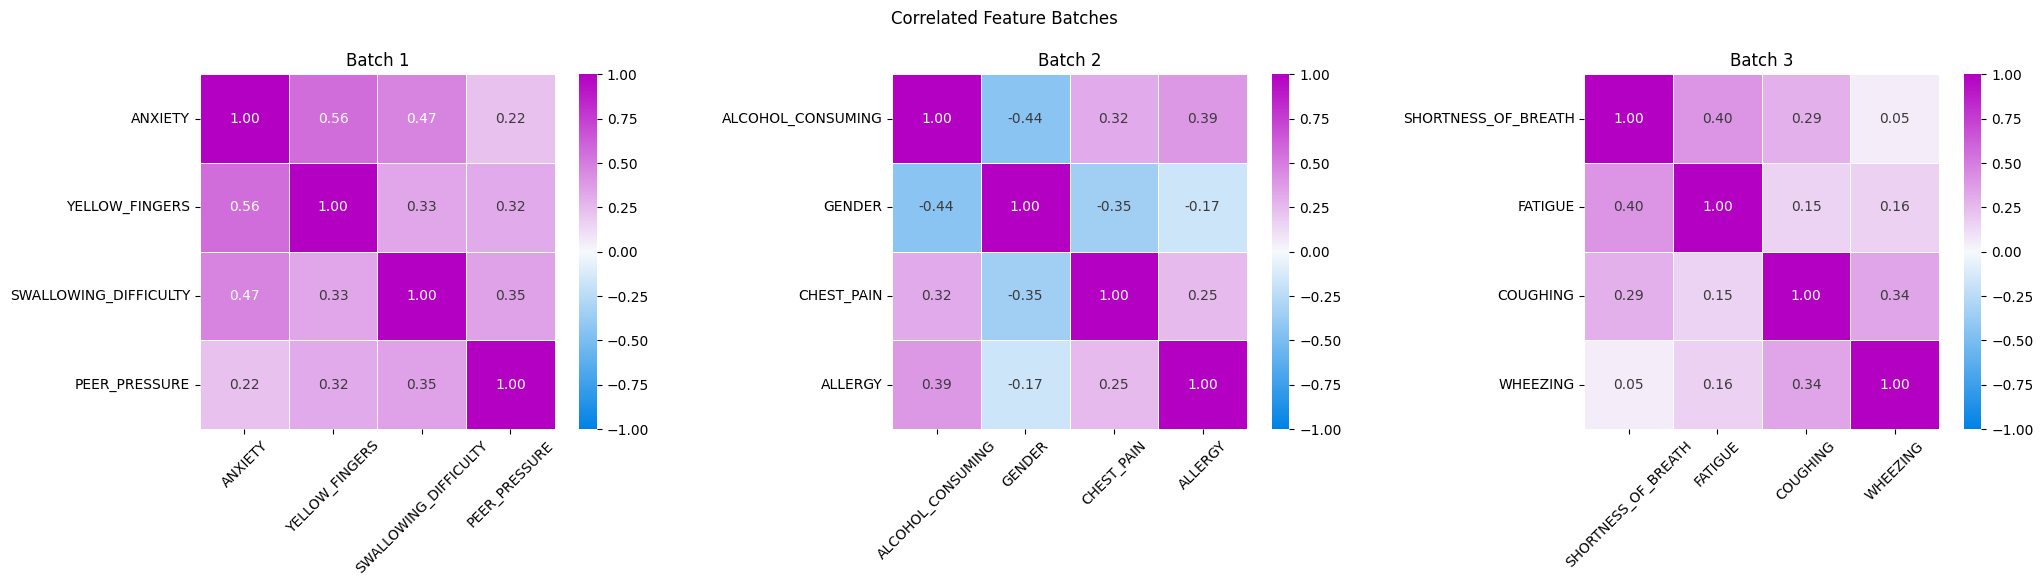

In [25]:
intercorrelation_feature_columns = [
    feature_name
    for feature_name in t_test_feature_columns
    if feature_name not in engineered_features
]

feature_signed_correlation_matrix = dataset_clean[intercorrelation_feature_columns].corr()
feature_peer_correlation_matrix = feature_signed_correlation_matrix.abs()
feature_mean_peer_correlation = (
    (feature_peer_correlation_matrix.sum(axis=1) - 1)
    / (len(intercorrelation_feature_columns) - 1)
).sort_values(ascending=False)

top_intercorrelated_features = feature_mean_peer_correlation.head(12).index.tolist()
batch_size = 4
batch_columns = [
    "Feature",
    "Mean absolute correlation with other tested features",
    "Mean absolute correlation within batch",
    "Mean (No Cancer)",
    "Mean (Cancer)",
    "t-statistic",
    "p-value",
    "Significant (p < 0.05)",
]

remaining_features = top_intercorrelated_features.copy()
batch_results_list = []
batch_feature_sets = []

while len(remaining_features) >= batch_size:
    best_pair = None
    best_pair_correlation = -1
    for left_index, left_feature in enumerate(remaining_features):
        for right_feature in remaining_features[left_index + 1:]:
            pair_correlation = feature_peer_correlation_matrix.loc[left_feature, right_feature]
            if pair_correlation > best_pair_correlation:
                best_pair_correlation = pair_correlation
                best_pair = [left_feature, right_feature]

    current_batch = best_pair.copy()
    candidate_features = [
        feature_name for feature_name in remaining_features if feature_name not in current_batch
    ]

    while len(current_batch) < batch_size and candidate_features:
        next_feature = max(
            candidate_features,
            key=lambda feature_name: sum(
                feature_peer_correlation_matrix.loc[feature_name, grouped_feature]
                for grouped_feature in current_batch
            ) / len(current_batch),
        )
        current_batch.append(next_feature)
        candidate_features.remove(next_feature)

    batch_correlation_matrix = feature_peer_correlation_matrix.loc[current_batch, current_batch]
    batch_mean_correlation = (
        batch_correlation_matrix.values.sum() - len(current_batch)
    ) / (len(current_batch) * (len(current_batch) - 1))

    batch_results = all_t_test_results_df[
        all_t_test_results_df["Feature"].isin(current_batch)
    ].copy()
    batch_results["Mean absolute correlation with other tested features"] = batch_results[
        "Feature"
    ].map(feature_mean_peer_correlation)
    batch_results["Mean absolute correlation within batch"] = batch_results["Feature"].map(
        lambda feature_name: batch_correlation_matrix.loc[feature_name].drop(feature_name).mean()
    )
    batch_results["Batch mean absolute correlation"] = batch_mean_correlation
    batch_results_list.append(batch_results)
    batch_feature_sets.append(
        {
            "features": current_batch,
            "batch_mean_absolute_correlation": batch_mean_correlation,
        }
    )

    remaining_features = [
        feature_name for feature_name in remaining_features if feature_name not in current_batch
    ]

correlated_feature_batches_df = pd.concat(batch_results_list, ignore_index=True)
batch_order = (
    correlated_feature_batches_df[["Batch mean absolute correlation"]]
    .drop_duplicates()
    .sort_values("Batch mean absolute correlation", ascending=False)
    .reset_index(drop=True)
)
batch_label_map = {
    batch_mean: f"Batch {batch_number}"
    for batch_number, batch_mean in enumerate(
        batch_order["Batch mean absolute correlation"],
        start=1,
    )
}
correlated_feature_batches_df["Batch"] = correlated_feature_batches_df[
    "Batch mean absolute correlation"
].map(batch_label_map)
batch_feature_map = {
    batch_label_map[batch_definition["batch_mean_absolute_correlation"]]: batch_definition[
        "features"
    ]
    for batch_definition in batch_feature_sets
}
batch_correlation_matrices = {
    batch_name: feature_signed_correlation_matrix.loc[feature_list, feature_list].round(2)
    for batch_name, feature_list in batch_feature_map.items()
}
correlated_feature_batches_df = correlated_feature_batches_df[
    [
        "Batch",
        "Feature",
        "Mean absolute correlation with other tested features",
        "Mean absolute correlation within batch",
        "Mean (No Cancer)",
        "Mean (Cancer)",
        "t-statistic",
        "p-value",
        "Significant (p < 0.05)",
    ]
]
correlated_feature_batches_df = correlated_feature_batches_df.sort_values(
    ["Batch", "Mean absolute correlation within batch"],
    ascending=[True, False],
).reset_index(drop=True)

ordered_batch_names = sorted(batch_correlation_matrices)
fig, axes = plt.subplots(1, len(ordered_batch_names), figsize=(7 * len(ordered_batch_names), 5.5))
if len(ordered_batch_names) == 1:
    axes = [axes]

for axis, batch_name in zip(axes, ordered_batch_names):
    batch_matrix = batch_correlation_matrices[batch_name]
    sns.heatmap(
        batch_matrix,
        ax=axis,
        annot=True,
        fmt='.2f',
        cmap=section4_heatmap_cmap,
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar=True,
        annot_kws={'fontsize': 10},
    )
    for text, value in zip(axis.texts, batch_matrix.to_numpy().flatten()):
        text.set_color('white' if abs(value) >= 0.45 else section4_neutral_color)
    axis.set_title(batch_name)
    axis.tick_params(axis='x', rotation=45)
    axis.tick_params(axis='y', rotation=0)

plt.suptitle('Correlated Feature Batches', y=1.02)
plt.tight_layout()
plt.show()


### 4.5.2 Categorical/binary features vs lung cancer
The binary feature comparisons show that several symptom and lifestyle indicators are elevated in the positive class. This supports testing flexible non-linear models, because many of these signals are likely to interact rather than act independently. Figure 23 converts the binary-feature means from Table 29 into within-class yes-shares so the strongest class gaps are easier to compare visually.



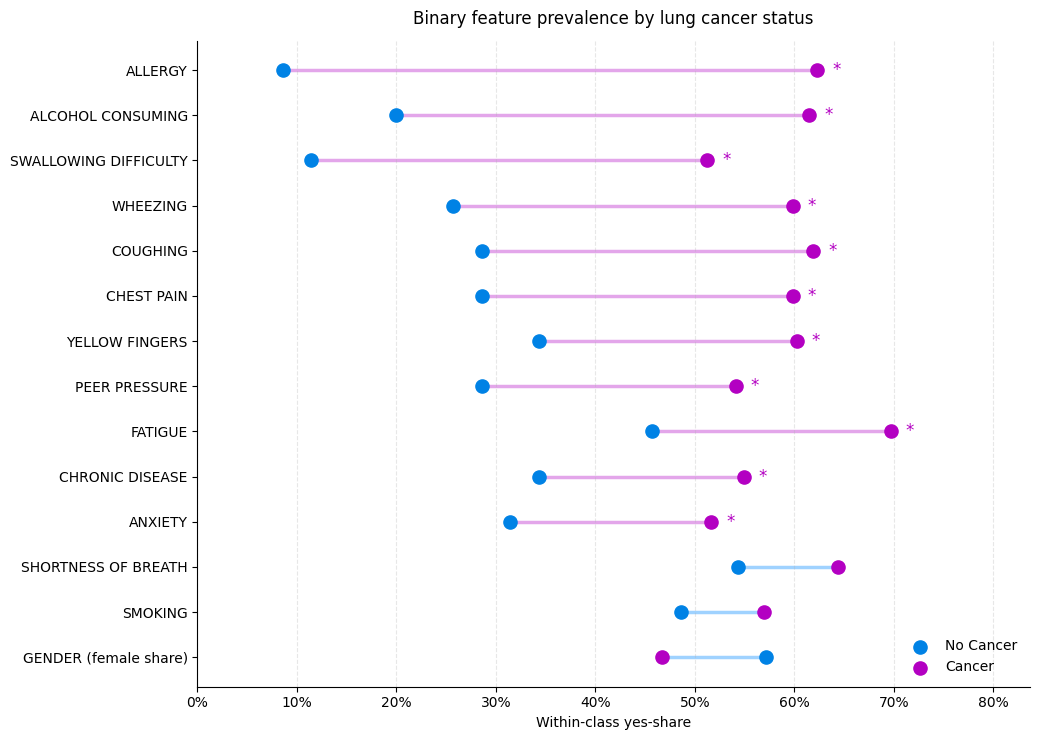

In [26]:
from matplotlib.ticker import PercentFormatter

binary_feature_plot_df = original_feature_t_test_results_df.loc[
    original_feature_t_test_results_df['Feature'] != 'AGE',
    ['Feature', 'Mean (No Cancer)', 'Mean (Cancer)', 'p-value'],
].copy()

binary_feature_plot_df['Difference'] = (
    binary_feature_plot_df['Mean (Cancer)'] - binary_feature_plot_df['Mean (No Cancer)']
)
binary_feature_plot_df['Feature Label'] = binary_feature_plot_df['Feature'].str.replace('_', ' ', regex=False)
binary_feature_plot_df.loc[
    binary_feature_plot_df['Feature'] == 'GENDER',
    'Feature Label',
] = 'GENDER (female share)'
binary_feature_plot_df = binary_feature_plot_df.sort_values('Difference', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 7.5))
y_positions = list(range(len(binary_feature_plot_df)))
max_share = max(
    binary_feature_plot_df['Mean (No Cancer)'].max(),
    binary_feature_plot_df['Mean (Cancer)'].max(),
)
upper_limit = min(1.0, max_share + 0.14)

for idx, row in binary_feature_plot_df.iterrows():
    line_color = section4_primary_light if row['p-value'] < alpha else section4_secondary_light
    ax.plot(
        [row['Mean (No Cancer)'], row['Mean (Cancer)']],
        [idx, idx],
        color=line_color,
        linewidth=2.5,
        solid_capstyle='round',
        zorder=1,
    )
    if row['p-value'] < alpha:
        ax.text(
            min(upper_limit - 0.01, max(row['Mean (No Cancer)'], row['Mean (Cancer)']) + 0.015),
            idx,
            '*',
            va='center',
            ha='left',
            fontsize=12,
            color=section4_primary_color,
        )

ax.scatter(
    binary_feature_plot_df['Mean (No Cancer)'],
    y_positions,
    color=section4_secondary_color,
    s=90,
    label='No Cancer',
    zorder=3,
)
ax.scatter(
    binary_feature_plot_df['Mean (Cancer)'],
    y_positions,
    color=section4_primary_color,
    s=90,
    label='Cancer',
    zorder=4,
)

ax.set_yticks(y_positions)
ax.set_yticklabels(binary_feature_plot_df['Feature Label'])
ax.set_xlim(0, upper_limit)
ax.set_xlabel('Within-class yes-share')
ax.set_ylabel('')
ax.set_title('Binary feature prevalence by lung cancer status', pad=12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()

_display_centered_matplotlib_figure(
    fig,
    max_width='88%',
    caption='Figure 23. Within-class yes-share of each original binary feature by lung cancer status, ordered by the cancer-minus-no-cancer gap. Asterisks mark Welch-test significance at p < 0.05.',
)


### 4.5.3 Age vs lung cancer
Age shows a weaker and more graded relationship with the target than the strongest symptom features. That makes age useful context rather than the single dominant predictor in the modelling stage. Figure 24 combines a box-and-strip view with overlapping age distributions to show that the class shift is modest and heavily overlapping.



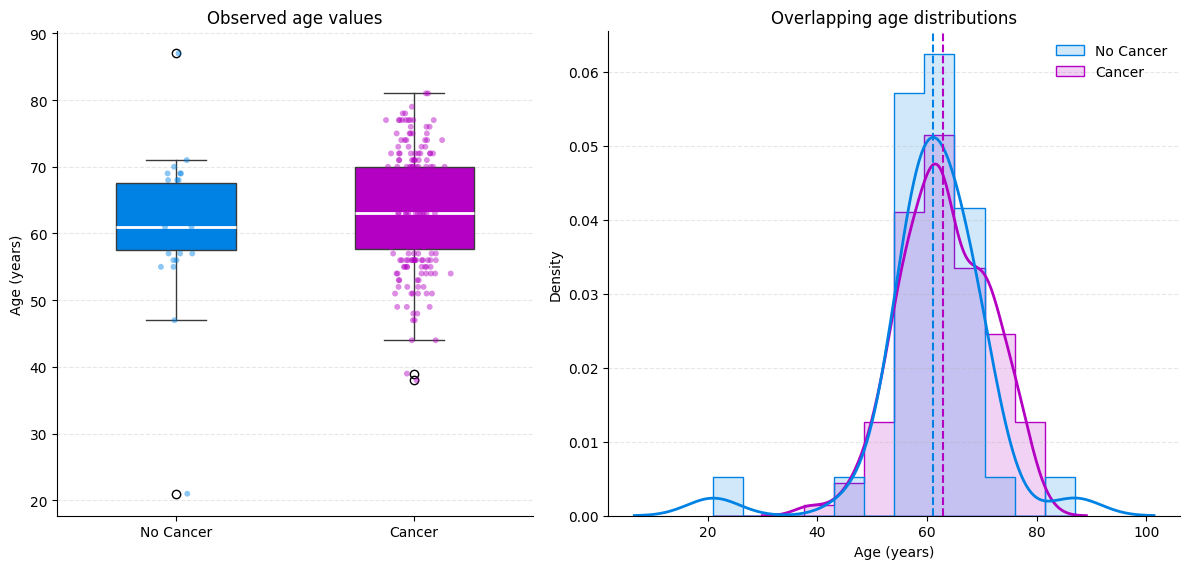

In [27]:
import numpy as np

age_plot_df = dataset_clean[['AGE', 'LUNG_CANCER']].copy()
age_plot_df['Lung Cancer Status'] = age_plot_df['LUNG_CANCER'].map({0: 'No Cancer', 1: 'Cancer'})
age_palette = {'No Cancer': section4_secondary_color, 'Cancer': section4_primary_color}

no_cancer_ages = age_plot_df.loc[age_plot_df['Lung Cancer Status'] == 'No Cancer', 'AGE']
cancer_ages = age_plot_df.loc[age_plot_df['Lung Cancer Status'] == 'Cancer', 'AGE']

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.8),
    gridspec_kw={'width_ratios': [1, 1.2]},
)

boxplot = axes[0].boxplot(
    [no_cancer_ages, cancer_ages],
    tick_labels=['No Cancer', 'Cancer'],
    patch_artist=True,
    widths=0.5,
    medianprops={'color': 'white', 'linewidth': 2},
)
for patch, label in zip(boxplot['boxes'], ['No Cancer', 'Cancer']):
    patch.set_facecolor(age_palette[label])
    patch.set_edgecolor(section4_neutral_color)
for whisker in boxplot['whiskers']:
    whisker.set_color(section4_neutral_color)
for cap in boxplot['caps']:
    cap.set_color(section4_neutral_color)

rng = np.random.default_rng(0)
for xpos, label, ages in [(1, 'No Cancer', no_cancer_ages), (2, 'Cancer', cancer_ages)]:
    jitter = rng.normal(loc=xpos, scale=0.05, size=len(ages))
    axes[0].scatter(
        jitter,
        ages,
        s=18,
        alpha=0.45,
        color=age_palette[label],
        edgecolors='none',
        zorder=3,
    )

axes[0].set_title('Observed age values')
axes[0].set_xlabel('')
axes[0].set_ylabel('Age (years)')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

sns.histplot(
    data=age_plot_df,
    x='AGE',
    hue='Lung Cancer Status',
    hue_order=['No Cancer', 'Cancer'],
    palette=age_palette,
    bins=12,
    stat='density',
    common_norm=False,
    element='step',
    fill=True,
    alpha=0.18,
    ax=axes[1],
)
sns.kdeplot(
    data=age_plot_df,
    x='AGE',
    hue='Lung Cancer Status',
    hue_order=['No Cancer', 'Cancer'],
    palette=age_palette,
    common_norm=False,
    linewidth=2,
    legend=False,
    ax=axes[1],
)
for label, color in age_palette.items():
    median_age = age_plot_df.loc[age_plot_df['Lung Cancer Status'] == label, 'AGE'].median()
    axes[1].axvline(median_age, color=color, linestyle='--', linewidth=1.5)

axes[1].set_title('Overlapping age distributions')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
if axes[1].legend_ is not None:
    axes[1].legend_.set_frame_on(False)
    axes[1].legend_.set_title('')

plt.tight_layout()

_display_centered_matplotlib_figure(
    fig,
    max_width='92%',
    caption='Figure 24. Age distribution by lung cancer status, shown as a box-and-strip plot and overlapping density curves.',
)


### 4.5.4 Gender subgroup analysis
The gender subgroup plots are descriptive rather than definitive because the dataset is small. They are still useful for checking whether the main symptom patterns appear broadly similar across the two recorded groups.


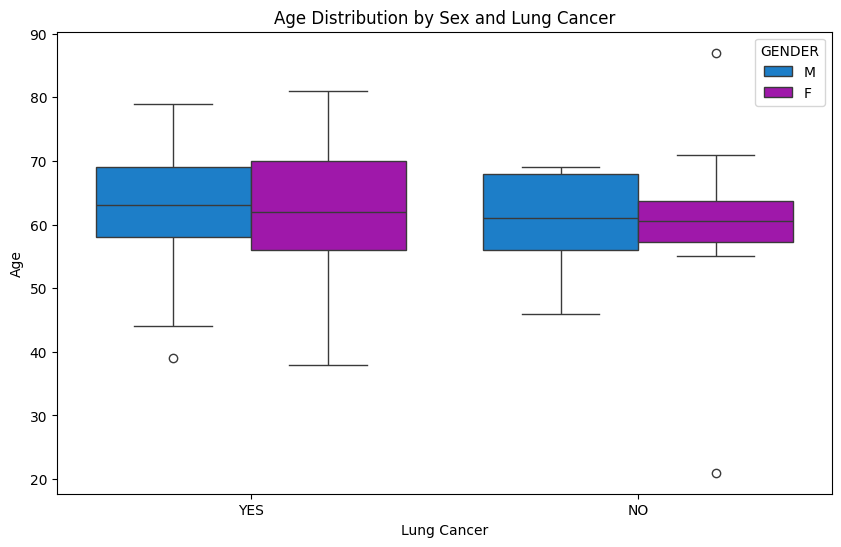

In [28]:
# Check dataset shape, column names, data types, and summary info
gender_palette = {'M': section4_secondary_color, 'F': section4_primary_color}
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=dataset,
    x='LUNG_CANCER',
    y='AGE',
    hue='GENDER',
    palette=gender_palette,
)
plt.title('Age Distribution by Sex and Lung Cancer')
plt.xlabel('Lung Cancer')
plt.ylabel('Age')
plt.show()


## 4.6 Correlation and multicollinearity review
The correlation review checks whether the strongest features are also redundant with one another. That matters because highly related symptom variables can inflate the apparent amount of signal without truly adding independent information.


### 4.6.1 Feature relationships
Several respiratory and lifestyle variables move together, which is expected because symptoms such as wheezing, coughing, and shortness of breath often cluster. This pattern motivated the batch-derived composite features and supports testing tree-based models that can exploit interactions.


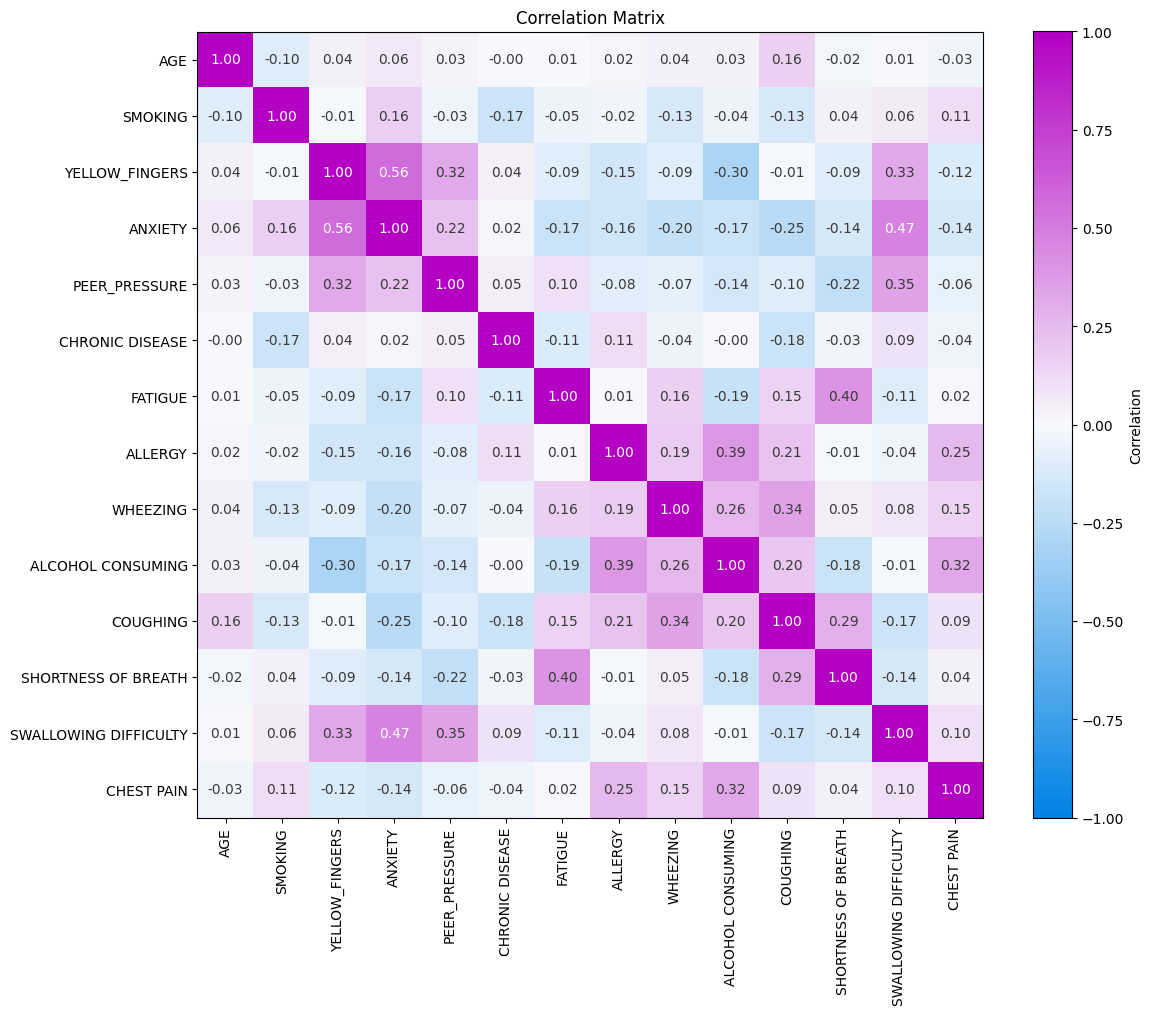

In [29]:
corr_matrix = dataset_dedup.corr(numeric_only=True)

corr_fig, corr_ax = plt.subplots(figsize=(12, 10))
corr_image = corr_ax.imshow(corr_matrix, cmap=section4_heatmap_cmap, vmin=-1, vmax=1)
corr_fig.colorbar(corr_image, label='Correlation', ax=corr_ax)
corr_ax.set_xticks(range(len(corr_matrix.columns)))
corr_ax.set_xticklabels(corr_matrix.columns, rotation=90)
corr_ax.set_yticks(range(len(corr_matrix.index)))
corr_ax.set_yticklabels(corr_matrix.index)
corr_ax.set_title('Correlation Matrix')

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(corr_value) >= 0.45 else section4_neutral_color
        corr_ax.text(j, i, f'{corr_value:.2f}', ha='center', va='center', color=text_color)

plt.tight_layout()
plt.show()


### 4.6.2 Implications for modelling
Because the predictors are partly correlated and largely binary, both a regularised linear baseline and non-linear tree ensembles are reasonable candidates. The shared pipeline later keeps preprocessing constant so that the comparison focuses on model behaviour rather than data handling differences, while the batch-derived composites give the models a compact summary of correlated groups without replacing the original variables entirely.


## 4.7 Interpretation of key patterns
The strongest patterns point to correlated symptom clusters rather than isolated single variables. That supports building modest batch-based composite features and argues against over-interpreting any one predictor on its own.


## 4.8 Visual insights that inform the ML strategy
The EDA suggests three modelling choices: preserve recall as a priority because the classes are imbalanced, test non-linear models because several features appear to interact, and keep the feature engineering interpretable because the dataset is small.


## 4.9 Data analysis summary
Overall, the exploratory analysis shows a small but structured post-cleaning dataset with a pronounced class imbalance (`244` cancer cases versus `35` no-cancer cases, or roughly `6.97:1`). That imbalance means raw accuracy alone would be misleading, so the later model comparison should continue to prioritise recall-sensitive measures, confusion matrices, and threshold-aware interpretation. Age remains useful contextual information, but its distributions overlap heavily across the two classes and the class shift is modest compared with the strongest binary predictors. By contrast, several symptom and lifestyle variables show much clearer target separation, with the largest class gaps appearing in `ALLERGY`, `SWALLOWING_DIFFICULTY`, `ALCOHOL_CONSUMING`, `WHEEZING`, `COUGHING`, and `CHEST_PAIN`, while `GENDER`, `SMOKING`, and `SHORTNESS_OF_BREATH` are weaker in this sample. The predictors are also partly correlated rather than independent, which justifies the batch-derived composite features and supports comparing interpretable linear baselines with non-linear models that can exploit interactions inside a leakage-safe shared pipeline.


## 4.10 Feature engineering decisions
This section turns the univariate and bivariate findings into the final feature choices used in modelling.

### 4.10.1 Batch-derived composite features
The bivariate testing showed that `BATCH_1`, `BATCH_2`, and `BATCH_3` all separate the two target groups, while Section 4.5.1 showed that their underlying variables form meaningful correlated clusters. Together, those results justify keeping the three batch-derived composites in the final modelling table as compact summaries of related symptom and lifestyle patterns, without removing the original predictors that preserve interpretability.

### 4.10.2 Age representation
The age plots suggested a gradual pattern rather than a single natural cut-off, so the final table keeps both representations of age. `AGE` is retained as a numeric variable and later min-max normalised inside the shared preprocessing pipeline, while `AGE_BINS` is kept as a grouped categorical feature to preserve the more interpretable banded view seen in the EDA.

### 4.10.3 Additional engineered features not retained
No extra ad hoc interactions or broad composite scores were added beyond these features. The EDA supported a restrained approach: keep the original predictors, add only the three correlation-based batch summaries plus `AGE_BINS`, and avoid creating extra variables that the exploratory evidence did not clearly justify.

### 4.10.4 Final modelling table
The final modelling table therefore keeps the original predictors alongside `BATCH_1`, `BATCH_2`, `BATCH_3`, and `AGE_BINS`, with all fitted preprocessing still applied later inside the modelling pipeline.


In [ ]:
# Hidden support cell retained so regression-tested final-model variables still exist
# even though Sections 5-7 have been cleared back to headings only.
features = model_dataset.drop(columns=['LUNG_CANCER'])
target = model_dataset['LUNG_CANCER']

numeric_features = [column_name for column_name in features.columns if column_name != 'AGE_BINS']
age_features = ['AGE']
other_numeric_features = [
    column_name for column_name in numeric_features if column_name not in age_features
]
categorical_features = ['AGE_BINS']

preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            other_numeric_features,
        ),
        (
            'categorical',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ]
)

candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, model in candidate_models.items():
    model_pipeline = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    cv_scores = cross_validate(
        model_pipeline,
        features,
        target,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    )
    cv_rows.append(
        {
            'Model': model_name,
            'Mean CV Accuracy': cv_scores['test_accuracy'].mean(),
            'Mean CV Precision': cv_scores['test_precision'].mean(),
            'Mean CV Recall': cv_scores['test_recall'].mean(),
            'Mean CV F1': cv_scores['test_f1'].mean(),
            'Mean CV ROC AUC': cv_scores['test_roc_auc'].mean(),
        }
    )

model_comparison_df = (
    pd.DataFrame(cv_rows)
    .sort_values(['Mean CV F1', 'Mean CV Recall'], ascending=False)
    .reset_index(drop=True)
)

final_model_name = model_comparison_df.loc[0, 'Model']

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    stratify=target,
    random_state=42,
)

final_pipeline = Pipeline(
    steps=[('preprocess', preprocess), ('model', candidate_models[final_model_name])]
)
final_pipeline.fit(X_train, y_train)

final_predictions = final_pipeline.predict(X_test)
final_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

final_metrics_df = pd.DataFrame(
    [
        {
            'Accuracy': accuracy_score(y_test, final_predictions),
            'Precision': precision_score(y_test, final_predictions),
            'Recall': recall_score(y_test, final_predictions),
            'F1': f1_score(y_test, final_predictions),
            'ROC AUC': roc_auc_score(y_test, final_probabilities),
        }
    ]
).round(4)

conf_matrix = confusion_matrix(y_test, final_predictions, labels=[0, 1])
confusion_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
)

precision_curve, recall_curve, threshold_values = precision_recall_curve(y_test, final_probabilities)
threshold_analysis_df = pd.DataFrame(
    {
        'Threshold': threshold_values,
        'Precision': precision_curve[1:],
        'Recall': recall_curve[1:],
    }
)
threshold_analysis_df['F1'] = (
    2
    * threshold_analysis_df['Precision']
    * threshold_analysis_df['Recall']
    / np.maximum(
        threshold_analysis_df['Precision'] + threshold_analysis_df['Recall'],
        1e-9,
    )
)
threshold_analysis_df = threshold_analysis_df.round(4)
high_recall_threshold_df = (
    threshold_analysis_df[threshold_analysis_df['Recall'] >= 0.95]
    .sort_values(['Precision', 'F1'], ascending=False)
    .reset_index(drop=True)
)

permutation_scores = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1',
)
feature_importance_df = (
    pd.DataFrame(
        {
            'Feature': features.columns,
            'Importance': permutation_scores.importances_mean,
        }
    )
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

error_analysis_df = X_test[['GENDER']].copy()
error_analysis_df['Actual'] = y_test.values
error_analysis_df['Predicted'] = final_predictions

subgroup_rows = []
for gender_value, gender_label in [(0, 'Male'), (1, 'Female')]:
    subgroup = error_analysis_df[error_analysis_df['GENDER'] == gender_value]
    subgroup_conf_matrix = confusion_matrix(subgroup['Actual'], subgroup['Predicted'], labels=[0, 1])
    subgroup_rows.append(
        {
            'Gender': gender_label,
            'Sample Size': int(len(subgroup)),
            'False Positives': int(subgroup_conf_matrix[0, 1]),
            'False Negatives': int(subgroup_conf_matrix[1, 0]),
            'Recall': recall_score(subgroup['Actual'], subgroup['Predicted']),
        }
    )

subgroup_error_df = pd.DataFrame(subgroup_rows).round(4)
model_comparison_df = model_comparison_df.round(4)
feature_importance_df = feature_importance_df.round(4)


# 5. Final Model Development


## 5.1 Recap of selected model type and feature engineering logic


### 5.1.1 Why Gaussian Naive Bayes was selected


### 5.1.2 Feature engineering logic carried forward


## 5.2 Baseline model


### 5.2.1 Gaussian Naive Bayes baseline configuration


### 5.2.2 Baseline performance metrics


## 5.3 Feature experiments


### 5.3.1 Engineered features included / excluded


#### 5.3.1.1 Experimental setup


#### 5.3.1.2 Performance metrics


### 5.3.2 Non-statistically significant features included / excluded


#### 5.3.2.1 Experimental setup


#### 5.3.2.2 Performance metrics


### 5.3.3 SMOTE used / not used


#### 5.3.3.1 Experimental setup


#### 5.3.3.2 Performance metrics


### 5.3.4 Age outlier included / excluded


#### 5.3.4.1 Experimental setup


#### 5.3.4.2 Performance metrics


## 5.4 Model hyperparameter optimisation


### 5.4.1 Tuning strategy


### 5.4.2 Selected hyperparameters


# 6. Final Performance Metrics


## 6.1 Core classification metrics


### 6.1.1 Final metric table


### 6.1.2 Confusion matrix


### 6.1.3 Threshold trade-offs


## 6.2 Final model interpretation


### 6.2.1 Feature importance and explainability


### 6.2.2 Error analysis


## 6.3 Final performance summary


### 6.3.1 Strengths


### 6.3.2 Limitations


### 6.3.3 Improvement ideas


# 7. Conclusion


## 7.1 Final model conclusion


### 7.1.1 Final selected configuration


### 7.1.2 Overall reflection
